# Indiana Pines

Class 1: 
* 1 datapoint - was able to get non-0 result, can't reproduce
* 3 datapoints - first non-0 result 
* 13 datapoints - somewhat acceptable result 

1. Import dependencies

In [1]:
import random
import torch
import multiprocessing
import numpy as np
import re
import time

import torch.utils.data as data

from typing import Optional, Sequence
from pathlib import Path
from typing import Callable
from dataclasses import dataclass
from typing import Any

from src.util.torch import resolve_torch_device
from src.util.hsi import (
    extract_patches,
    reduce_hsi_dim,
    preprocess_hsi,
    read_fixed_labels_mask_from_path,
    pu_bin_train_test_split_by_mask,
    PreProcessType,
    DimReductionType,
)
from src.data.indian_pines import load_indian_pines
from src.model.hsic import HyperSpectralImageClassifier
from src.visualization.plot import (
    plot_segmentation_comparison,
    plot_generic,
    plot_epoch_generic,
)
from src.data.dataset_decorator import UnlabeledDatasetDecorator, BinaryDatasetDecorator
from src.util.reporting import (
    create_model_name,
    report_run,
    classification_trainer,
)
from src.util.scheduler import CosineLRSchedulerWrapper
from src.model.dbda import DBDA
from src.model.representative_datapoints_search import (
    RepresentativeDataPointsSearchAdapter,
    RepresentativeDataPointsSearch,
)
from src.definitions import RAW_DATA_FOLDER, TMP_REPORTS_FOLDER
from src.util.loss import PuLoss
from src.model.autoencoder import AutoEncoderWithClassificationHead
from src.model.finetune import SimpleBinClassificationHead
from src.model.vit_hsi_decoder import ViTHsiDecoder
from src.trainer.base_trainer import AdamOptimizedModule, BaseTrainer, TrainableModule
from src.trainer.masked_autoencoder_trainer import HsiPatchMasking
from src.trainer.masked_autoencoder_with_classification_trainer import (
    MaskedAutoEncoderWithClasificationTrainer,
)
from src.util.loss import (
    MaskedAutoencoderLoss,
    MaskedAutoencoderWithClassificationHeadLoss,
    logistic_loss,
)
from src.trainer.model_storage import SimpleFileBackedModelStorage

2. Prepare env

In [2]:
epoch_seconds = int(time.time())

log_dir = TMP_REPORTS_FOLDER / f"bin-mae-pu-{epoch_seconds}"

mask_dir = Path(RAW_DATA_FOLDER / "mask" / "train-test-split")

In [3]:
learning_rate = 1e-3
weight_decay = 0
num_epochs = 10

In [4]:
batch_size = 64
patch_size = 9
target_dim = 75
target_class = 6
skip_maskes = 0

pre_process_type = PreProcessType.STANDARTIZATION
dim_reduction_type = DimReductionType.PCA

In [5]:
random_seed = 42

random.seed(random_seed)
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = resolve_torch_device()

In [6]:
torch.cuda.empty_cache()

In [7]:
torch.set_float32_matmul_precision("medium")

In [8]:
f"Device is {device}"

'Device is cuda'

3. Load dataset

In [9]:
image, labels = load_indian_pines()

image_h, image_w, image_c = image.shape

In [10]:
_, image = preprocess_hsi(image, pre_process_type)

In [11]:
_, target_dim, image = reduce_hsi_dim(
    image, target_dim, dim_reduction_type, device, random_seed
)

In [12]:
x, y = extract_patches(image, labels, patch_size=patch_size)

In [13]:
num_classes = len(np.unique(y))

f"Number of classes {num_classes}"

'Number of classes 17'

In [14]:
x_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2) 
y_tensor = torch.tensor(y, dtype=torch.long)

In [15]:
cpu_count = multiprocessing.cpu_count()

f"Setting num_workers to {cpu_count}"

'Setting num_workers to 24'

In [16]:
full_dataset = data.TensorDataset(x_tensor, y_tensor)

full_loader = data.DataLoader(
    BinaryDatasetDecorator(full_dataset, target_class),
    batch_size=batch_size,
    shuffle=False,
    num_workers=cpu_count,
    persistent_workers=True,
)
predict_loader = data.DataLoader(
    UnlabeledDatasetDecorator(full_dataset),
    batch_size=batch_size,
    num_workers=cpu_count,
    persistent_workers=True,
)

4. Train model

In [17]:
def extract_prediction(y_hat):
    return (torch.sigmoid(y_hat) > 0.5).to(dtype=torch.int)

In [18]:
@dataclass
class DatapointsSearchPipeline:
    trainer: BaseTrainer
    model: TrainableModule


class IndianPinesDatapointsSearch(
    RepresentativeDataPointsSearchAdapter[DatapointsSearchPipeline]
):
    target_class: int
    skip: int

    def __init__(self, target_class, skip=0):
        super().__init__()

        self.target_class = target_class
        self.skip = skip

    def get_run_params(
        self,
    ) -> Sequence[
        Callable[
            [], tuple[str, data.DataLoader, Optional[data.DataLoader], dict[str, Any]]
        ]
    ]:
        params = {
            "prediction_threshold": 0.5,
            "target_dim": target_dim,
            "latent_space_size": 256,
            "patch_size": 9,
            "decoder_embed_dim": 256,
            "decoder_layers": 8,
            "decoder_heads": 16,
            "decoder_mlp_dim": 512,
            "learning_rate": 1e-3,
            "weight_decay": 0.0,
            "loss_alpha": 1.0,
            "loss_beta": 0.1,
            "cls_loss_weight": 1.0,
            "num_epochs": 30,
            "mask_ratio": 0.75,
            "mask_mode": "spatial",
            "fill_value": "noise",
        }

        return [
            self.create_run_params(id, path, params)
            for id, path in self.load_partitions_by_class(self.target_class)
        ]

    def init_model(self, id: str, params: dict[str, Any]) -> HyperSpectralImageClassifier:
        torch.cuda.empty_cache()

        positive_count = (y == target_class).sum()
        all_count = len(y)
        positive_prob = torch.tensor(positive_count / all_count, dtype=torch.float32)

        pu_loss = PuLoss(
            prior=positive_prob,
            nnpu=True,
            loss_fn=logistic_loss,
        )

        encoder = DBDA(
            band=params["target_dim"],
            classes=params["latent_space_size"],
        )

        decoder = ViTHsiDecoder(
            latent_dim=params["latent_space_size"],
            out_h=params["patch_size"],
            out_w=params["patch_size"],
            out_bands=params["target_dim"],
            embed_dim=params["decoder_embed_dim"],
            n_layers=params["decoder_layers"],
            n_heads=params["decoder_heads"],
            mlp_dim=params["decoder_mlp_dim"],
        )

        cls_head = SimpleBinClassificationHead(params["latent_space_size"])

        model = AdamOptimizedModule(
            net=AutoEncoderWithClassificationHead(encoder, decoder, cls_head),
            lr=params["learning_rate"],
            weight_decay=params["weight_decay"],
        )

        trainer = MaskedAutoEncoderWithClasificationTrainer(
            loss_fun=MaskedAutoencoderWithClassificationHeadLoss(
                autoencoder_loss=MaskedAutoencoderLoss(
                    alpha=params["loss_alpha"], beta=params["loss_beta"]
                ),
                cls_loss=pu_loss,
                cls_loss_weight=params["cls_loss_weight"],
            ),
            num_classes=2,
            epochs=params["num_epochs"],
            masking=HsiPatchMasking(
                mask_ratio=params["mask_ratio"],
                mode=params["mask_mode"],
                fill_value=params["fill_value"],
            ),
            device=device,
            extract_prediction=extract_prediction,
            model_storage=SimpleFileBackedModelStorage(
                "eval_kappa",
                f"indian_pines_bin_mae_pu_{epoch_seconds}_{target_class}_{id}",
            ),
        )

        return DatapointsSearchPipeline(trainer=trainer, model=model)

    def fit_model(
        self,
        model: DatapointsSearchPipeline,
        train_loader: data.DataLoader,
        eval_loader: Optional[data.DataLoader],
        params: dict[str, Any],
    ) -> list[dict[str, float]]:
        feedback, trained_model = model.trainer.fit(
            model=model.model,
            train_dataloader=train_loader,
            eval_dataloader=eval_loader,
        )

        model.model = trained_model

        return [it.eval for it in feedback.history]

    def score_model(self, model: DatapointsSearchPipeline) -> dict[str, float]:
        trainer = model.trainer

        return trainer.validate(model.model, full_loader)

    def on_scored_model(
        self,
        id: str,
        params: dict[str, float],
        model: DatapointsSearchPipeline,
        model_history: list[dict[str, float]],
        score: dict[str, float],
    ):
        trainer = model.trainer
        model = model.model

        if model_history:
            losses = [it["eval_loss"] for it in model_history]
            kappas = [it["eval_kappa"] for it in model_history]
            plot_epoch_generic(
                losses, desc=f"Loss for class {self.target_class} ({id} examples)"
            )
            plot_epoch_generic(
                kappas, desc=f"Kappa for class {self.target_class} ({id} examples)"
            )

        y_pred = trainer.predict(model, predict_loader)[1]
        y_pred = torch.cat(y_pred, dim=0)
        y_pred = extract_prediction(y_pred)
        y_pred = y_pred.reshape(image_h, image_w)
        y_pred = y_pred.cpu()

        plot_segmentation_comparison(
            y.reshape(image_h, image_w) == self.target_class, y_pred.numpy()
        )

        model_name = create_model_name(f"indian_pines_", {target_class: id})
        model_category = "dbda"

        run_params = {
            **params,
            "batch_size": batch_size,
            "patch_size": patch_size,
            "target_dim": target_dim,
            "pre_process_type": str(pre_process_type),
            "dim_reduction_type": str(dim_reduction_type),
        }

        report_run(
            model_name=model_name,
            model_category=model_category,
            run_desc="Default run",
            run_params=run_params | model.get_params(),
            run_metrics=classification_trainer(score),
        )

    def load_partitions_by_class(self, clazz: int) -> list[tuple[str, Path]]:
        mask_arr = [
            (re.search(r"-(\d+)\.npy$", str(fn)).group(1), fn)
            for fn in mask_dir.glob(f"indian-pines-train-test-split-{clazz}-*.npy")
        ]

        return sorted(list(set(mask_arr)), key=lambda it: int(it[0]))[self.skip:]

    def create_dataloader_from_mask_file(
        self, path: Path
    ) -> tuple[data.DataLoader, data.DataLoader]:
        mask = read_fixed_labels_mask_from_path(path)

        x_train, y_train, _, _ = pu_bin_train_test_split_by_mask(
            self.target_class, x, y, mask
        )

        x_train_tensor = torch.tensor(x_train, dtype=torch.float32).permute(0, 3, 1, 2)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
        x_test_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
        y_test_tensor = torch.tensor(y == self.target_class, dtype=torch.float32)

        train_dataset = data.TensorDataset(x_train_tensor, y_train_tensor)
        test_dataset = data.TensorDataset(x_test_tensor, y_test_tensor)

        train_loader = data.DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=cpu_count,
            persistent_workers=True,
        )
        test_loader = data.DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=cpu_count,
            persistent_workers=True,
        )

        return train_loader, test_loader

    def create_run_params(
        self, id: str, path: Path, params: dict[str, float]
    ) -> Callable[
        [], tuple[str, data.DataLoader, Optional[data.DataLoader], dict[str, float]]
    ]:
        def curryng():
            loader, eval_loader = self.create_dataloader_from_mask_file(path)

            return id, loader, eval_loader, params

        return curryng

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

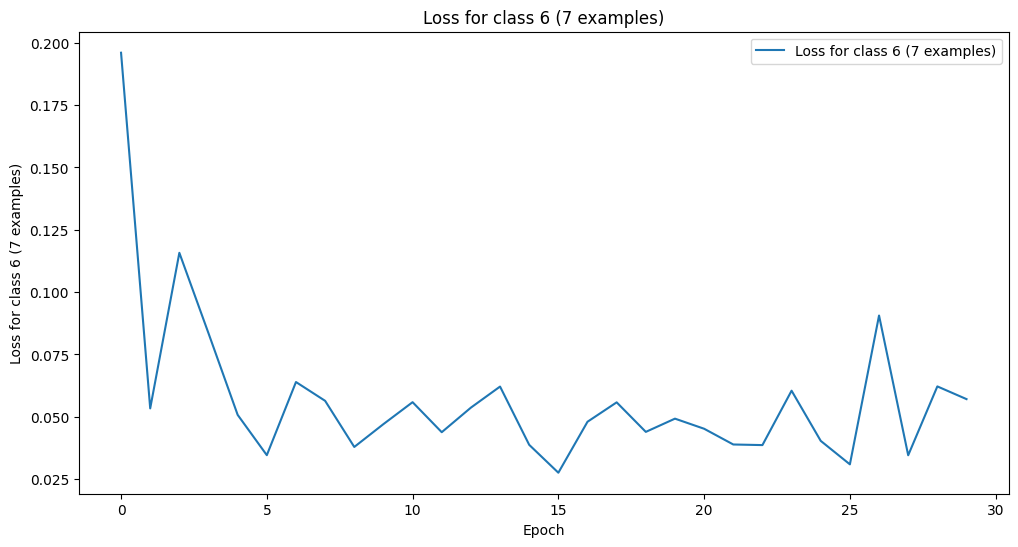

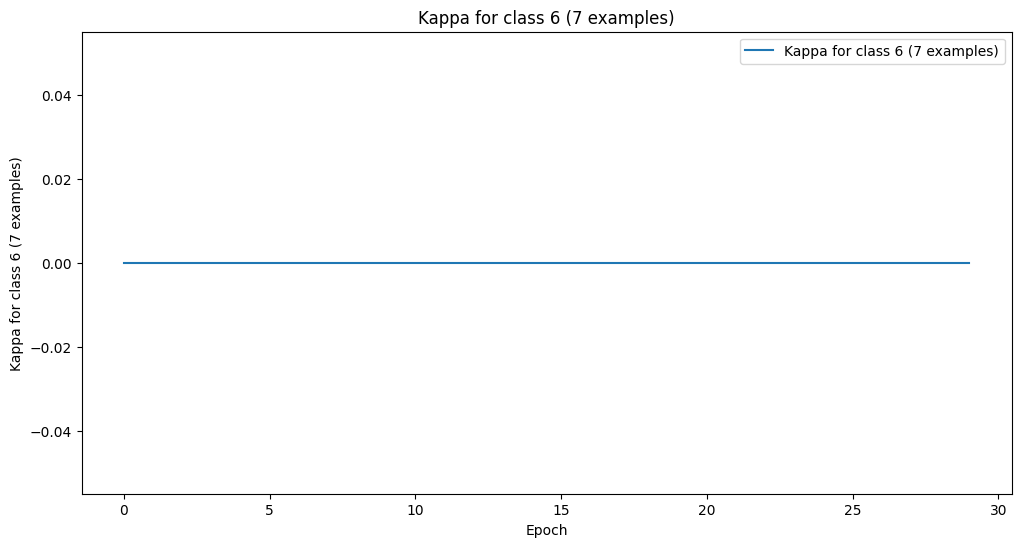

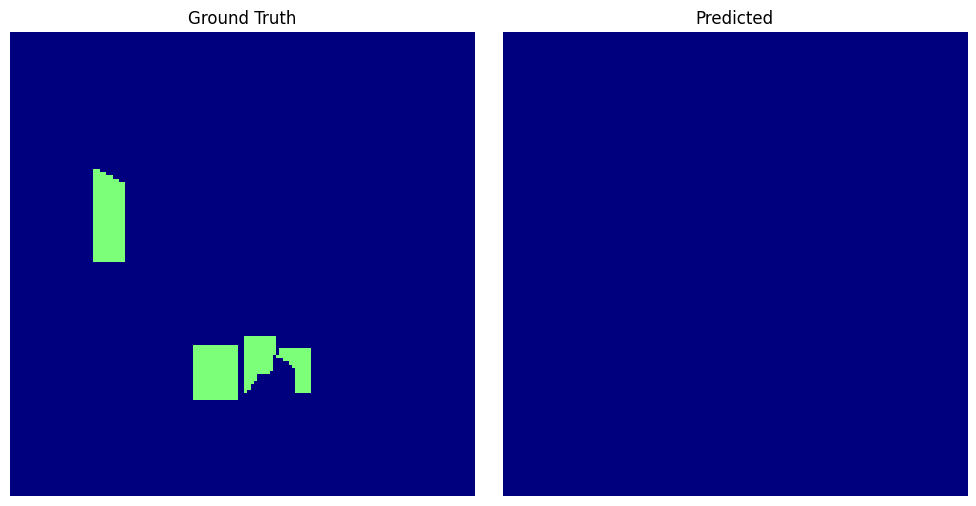

  6%|▌         | 1/18 [09:21<2:38:59, 561.16s/it, eval_accuracy_avg=0.965, eval_accuracy_overall=0.5, eval_f1=0.948, eval_kappa=0, eval_loss=0.196, id=7]

  0%|          | 0/30 [00:00<?, ?it/s]

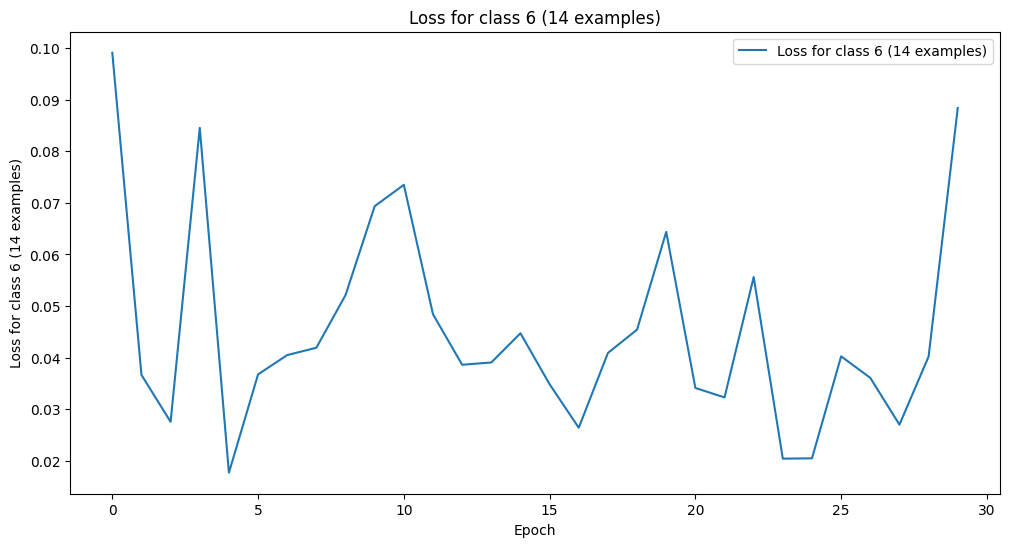

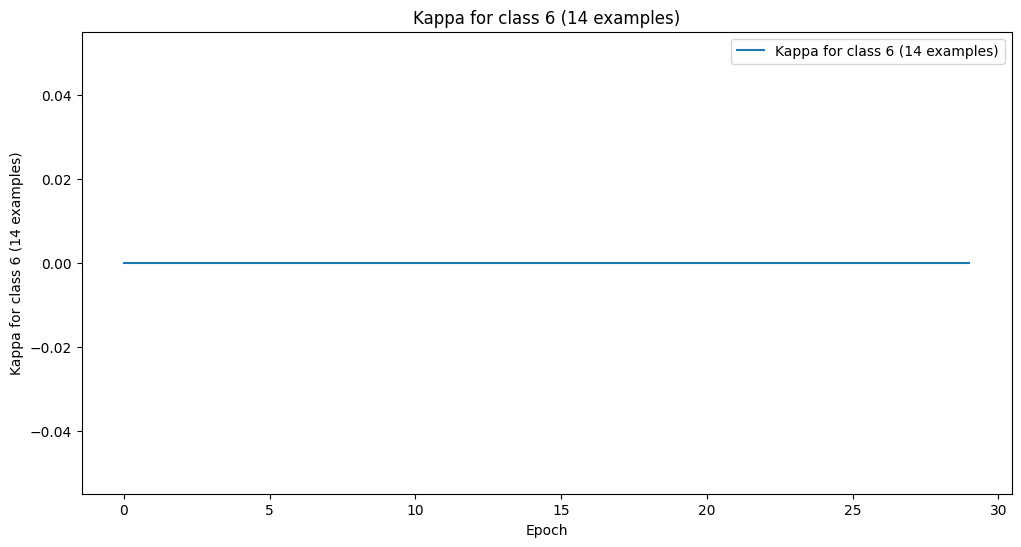

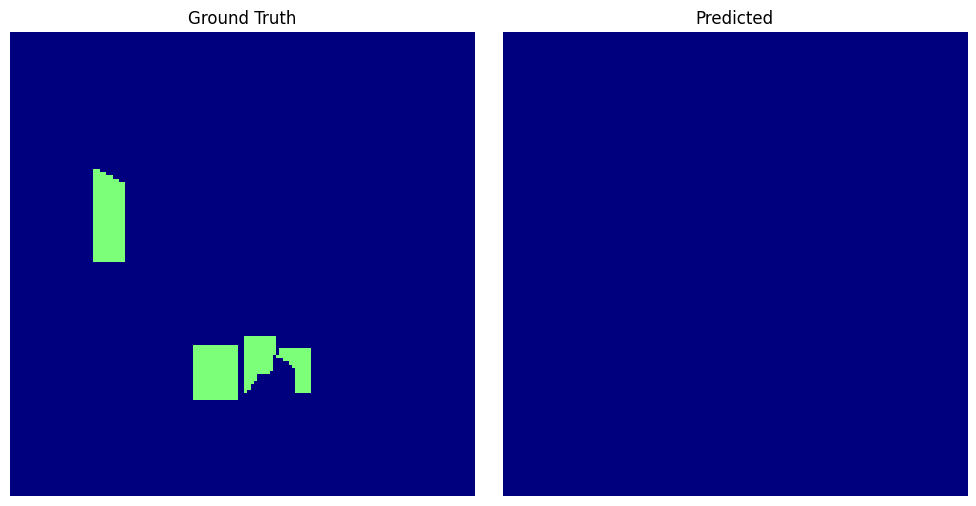

 11%|█         | 2/18 [18:50<2:30:53, 565.84s/it, eval_accuracy_avg=0.965, eval_accuracy_overall=0.5, eval_f1=0.948, eval_kappa=0, eval_loss=0.0991, id=14]

  0%|          | 0/30 [00:00<?, ?it/s]

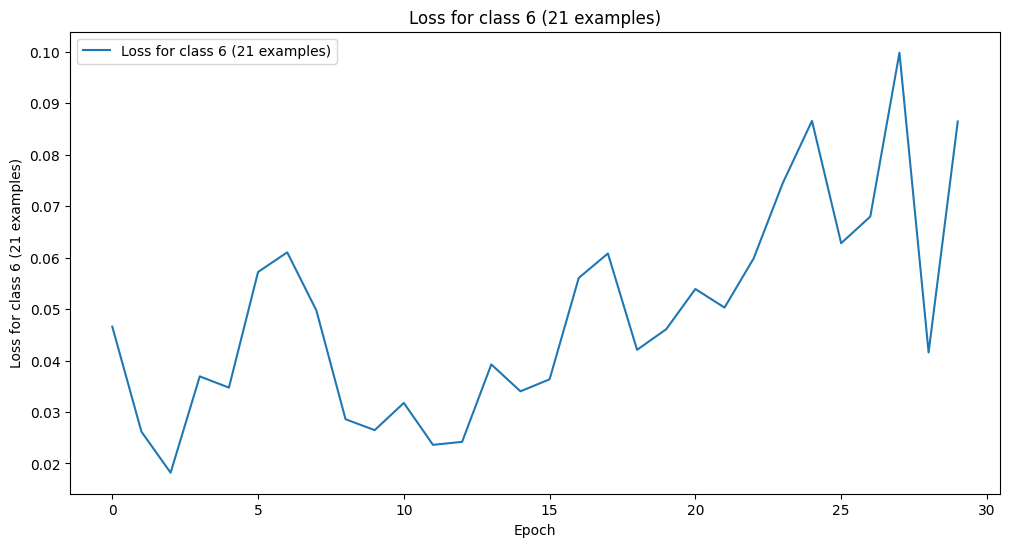

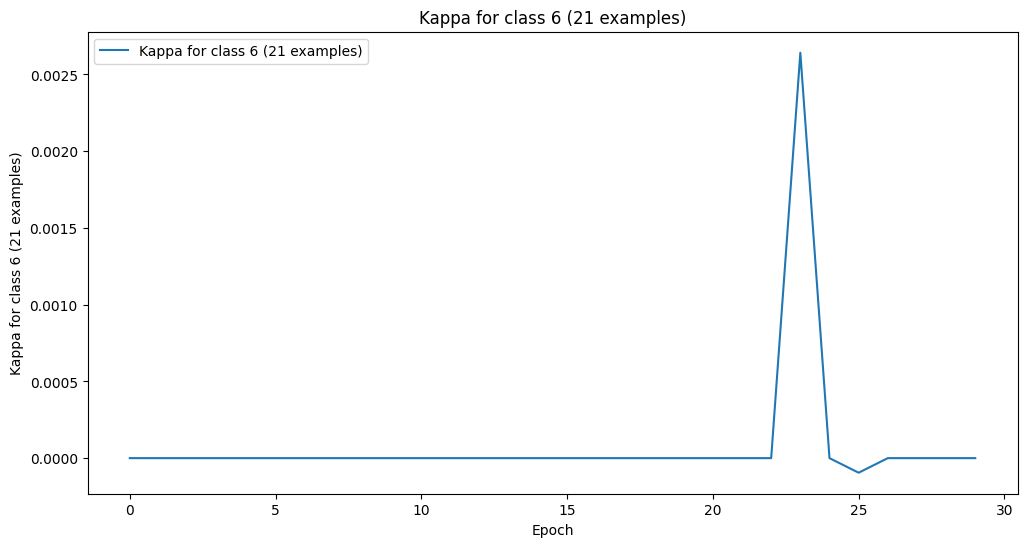

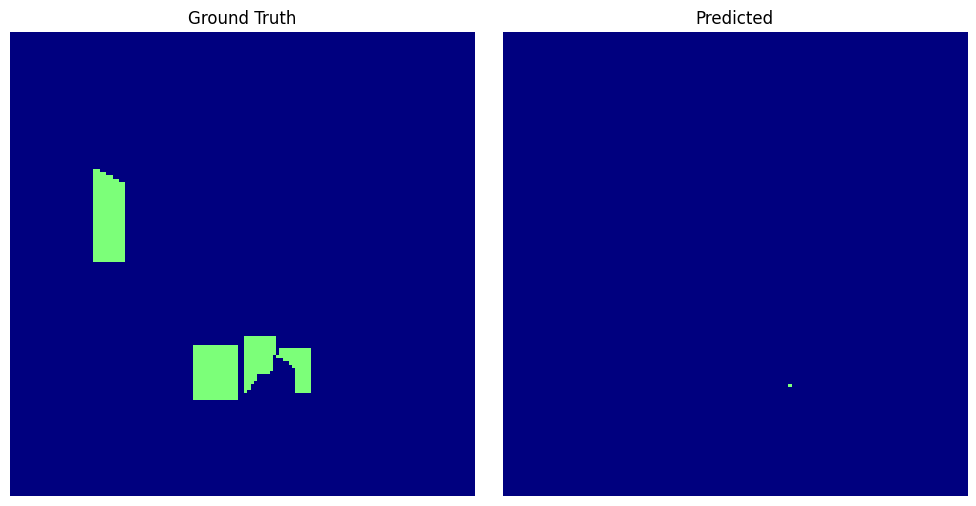

 17%|█▋        | 3/18 [28:06<2:20:24, 561.66s/it, eval_accuracy_avg=0.965, eval_accuracy_overall=0.501, eval_f1=0.948, eval_kappa=0.00264, eval_loss=0.0745, id=21]

  0%|          | 0/30 [00:00<?, ?it/s]

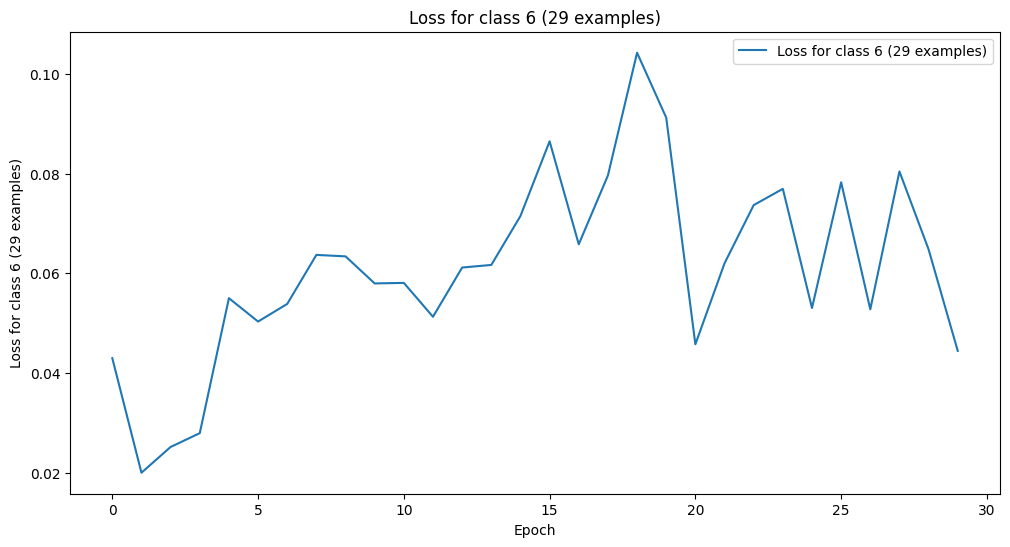

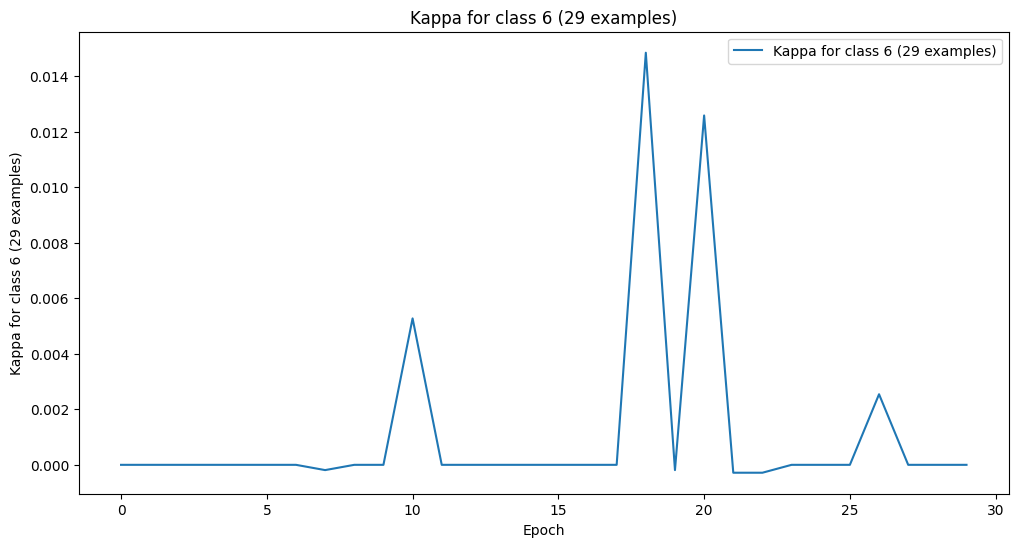

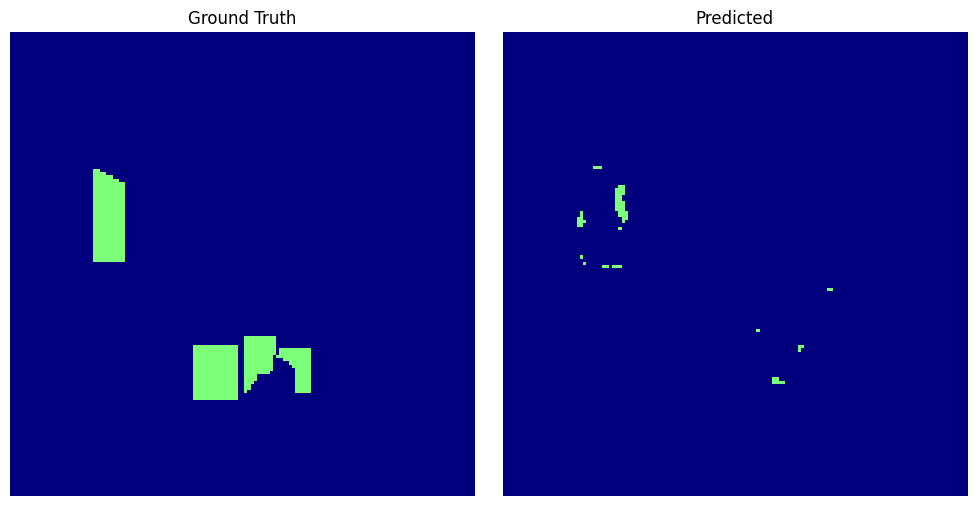

 22%|██▏       | 4/18 [37:56<2:13:38, 572.73s/it, eval_accuracy_avg=0.963, eval_accuracy_overall=0.504, eval_f1=0.948, eval_kappa=0.0148, eval_loss=0.104, id=29]  

  0%|          | 0/30 [00:00<?, ?it/s]

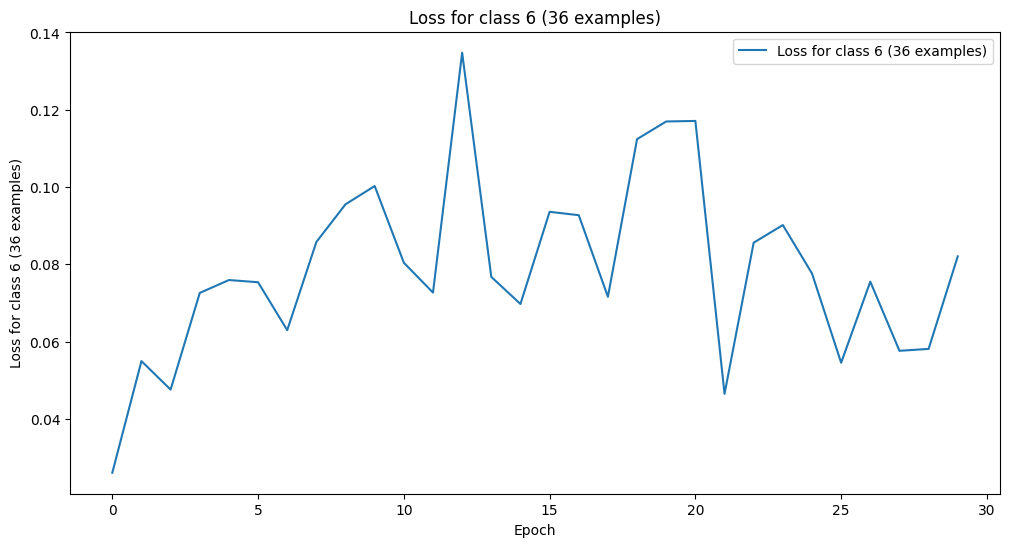

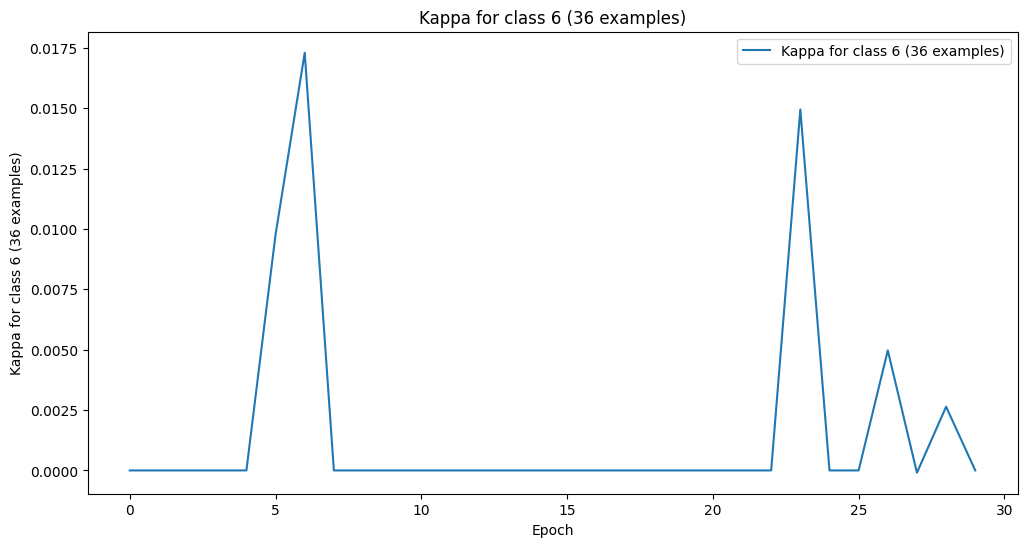

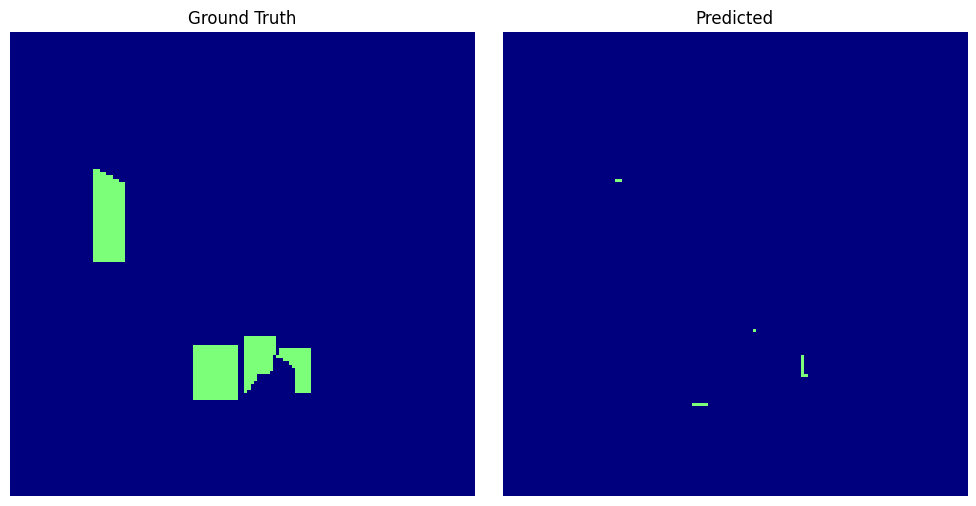

 28%|██▊       | 5/18 [47:31<2:04:15, 573.48s/it, eval_accuracy_avg=0.965, eval_accuracy_overall=0.505, eval_f1=0.949, eval_kappa=0.0173, eval_loss=0.0629, id=36]

  0%|          | 0/30 [00:00<?, ?it/s]

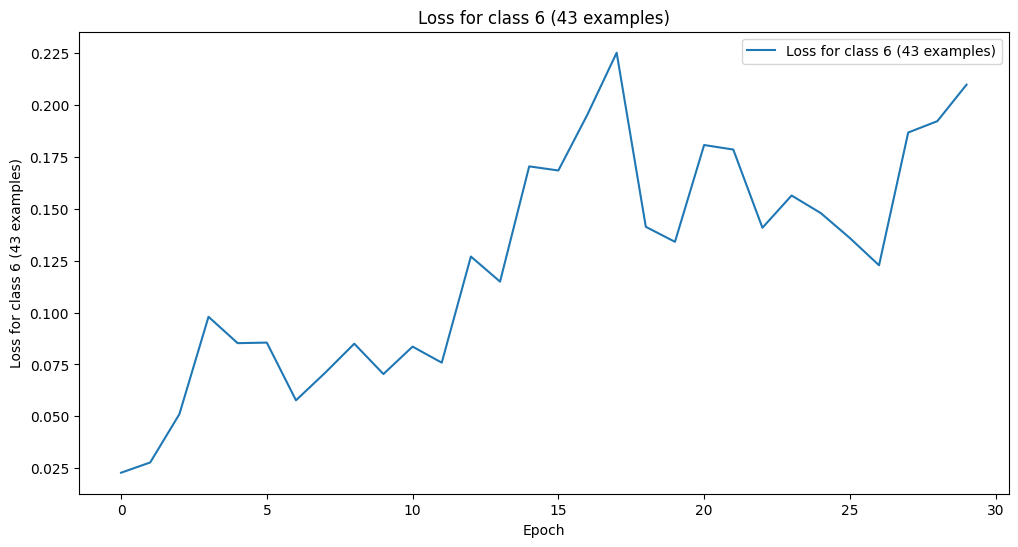

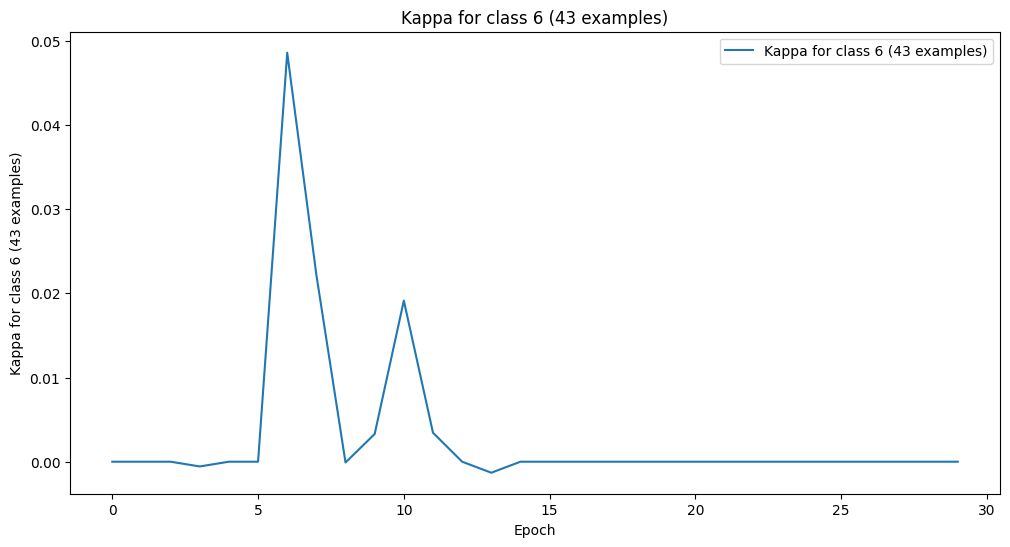

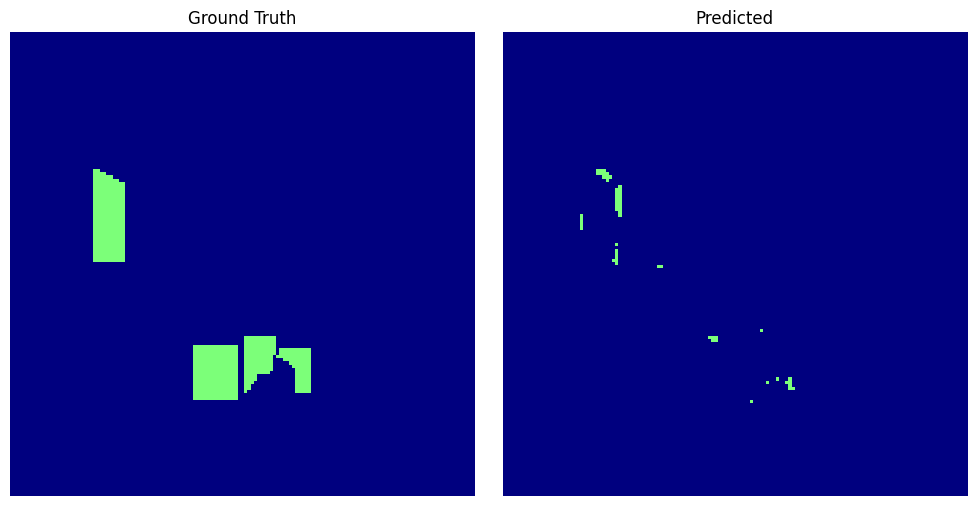

 33%|███▎      | 6/18 [56:30<1:52:20, 561.74s/it, eval_accuracy_avg=0.965, eval_accuracy_overall=0.513, eval_f1=0.95, eval_kappa=0.0486, eval_loss=0.0577, id=43] 

  0%|          | 0/30 [00:00<?, ?it/s]

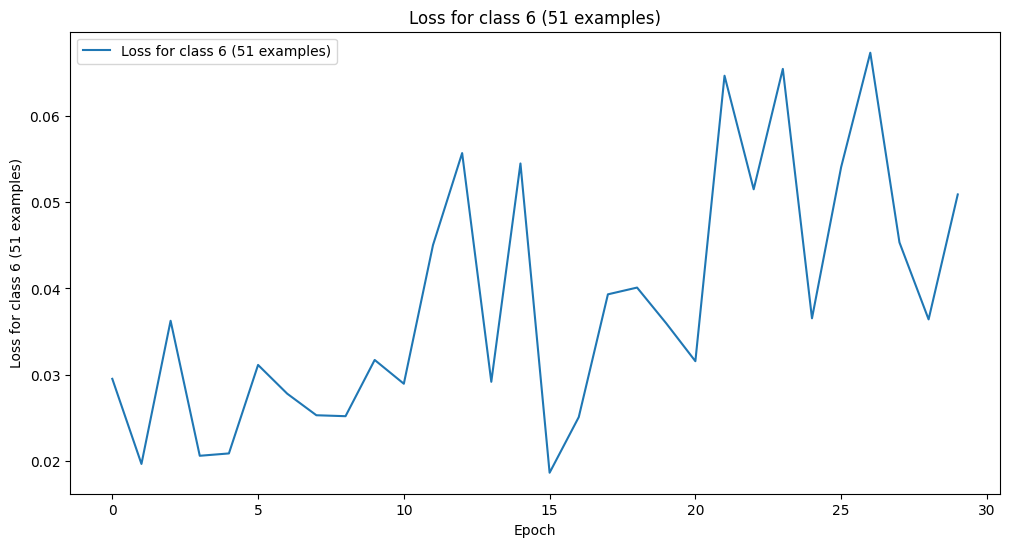

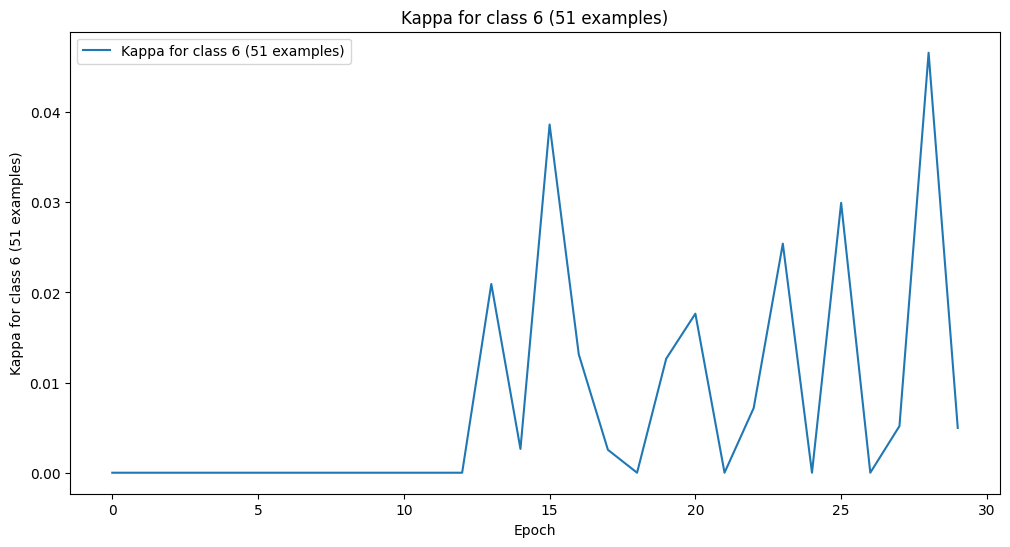

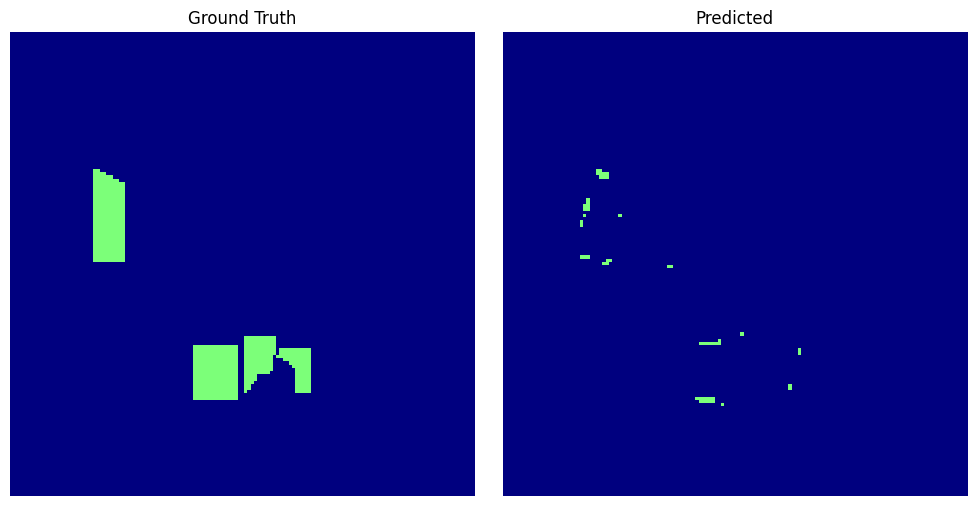

 39%|███▉      | 7/18 [1:05:39<1:42:13, 557.55s/it, eval_accuracy_avg=0.965, eval_accuracy_overall=0.513, eval_f1=0.95, eval_kappa=0.0466, eval_loss=0.0364, id=51]

  0%|          | 0/30 [00:00<?, ?it/s]

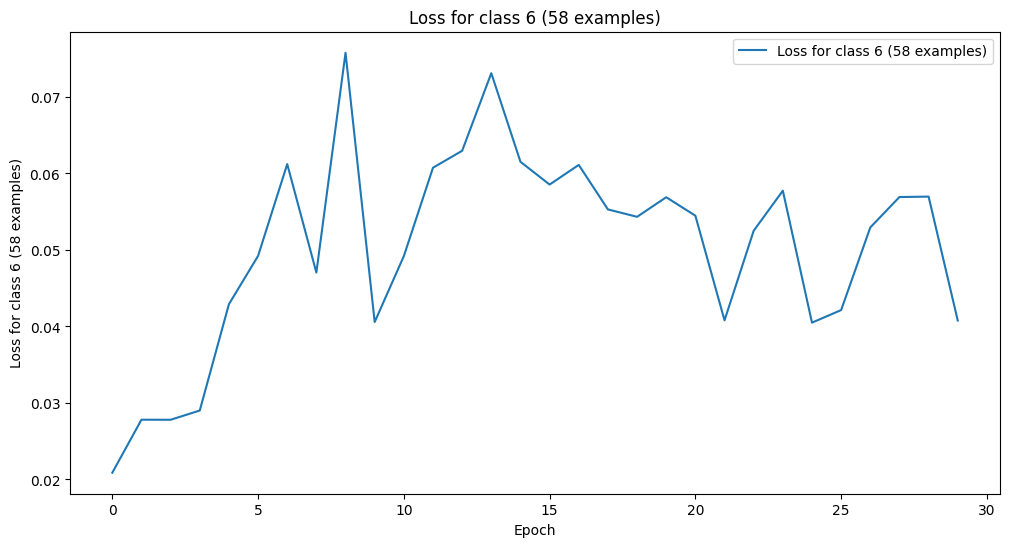

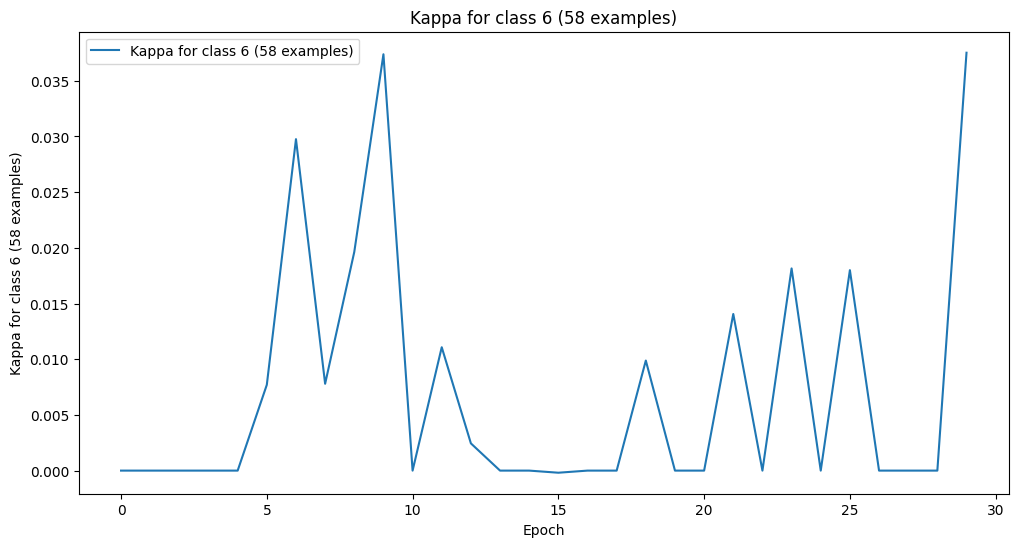

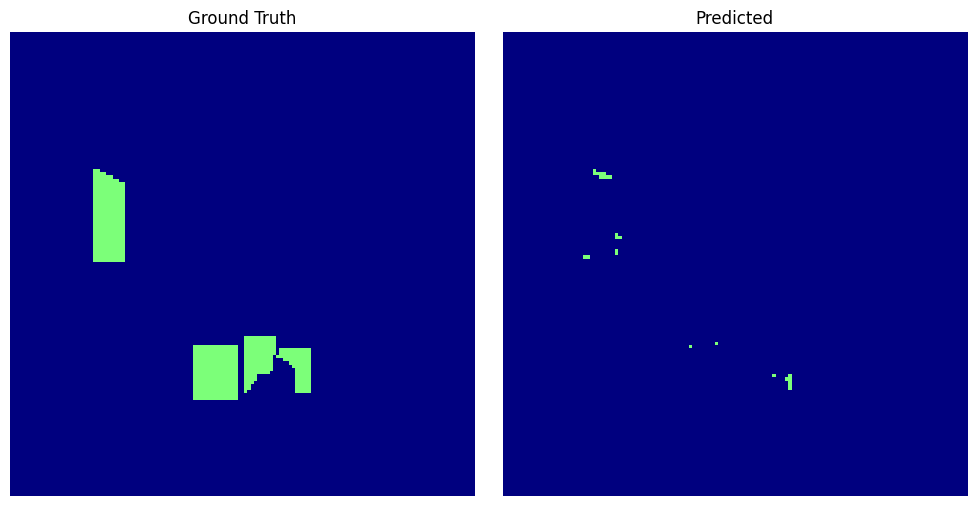

 44%|████▍     | 8/18 [1:15:02<1:33:13, 559.39s/it, eval_accuracy_avg=0.966, eval_accuracy_overall=0.51, eval_f1=0.95, eval_kappa=0.0375, eval_loss=0.0408, id=58] 

  0%|          | 0/30 [00:00<?, ?it/s]

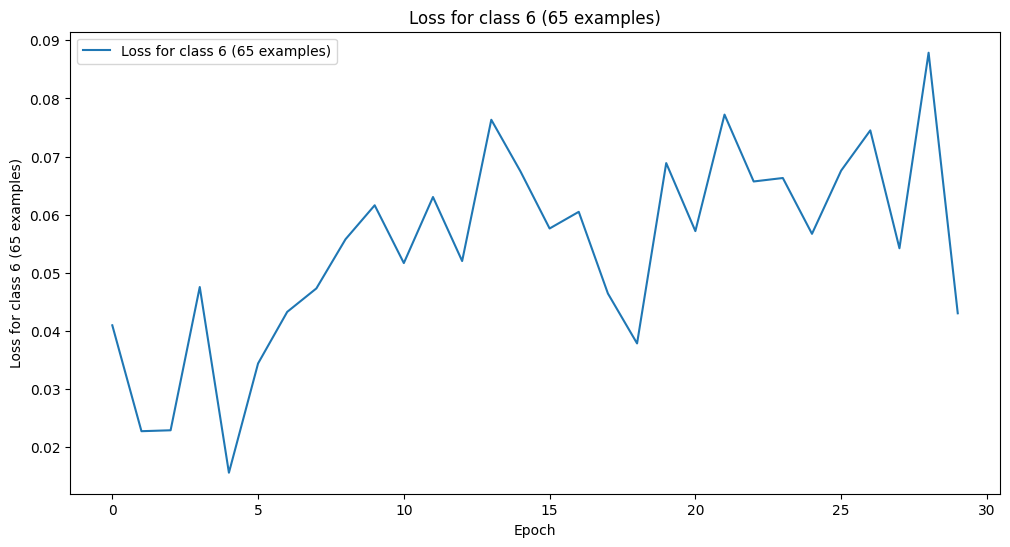

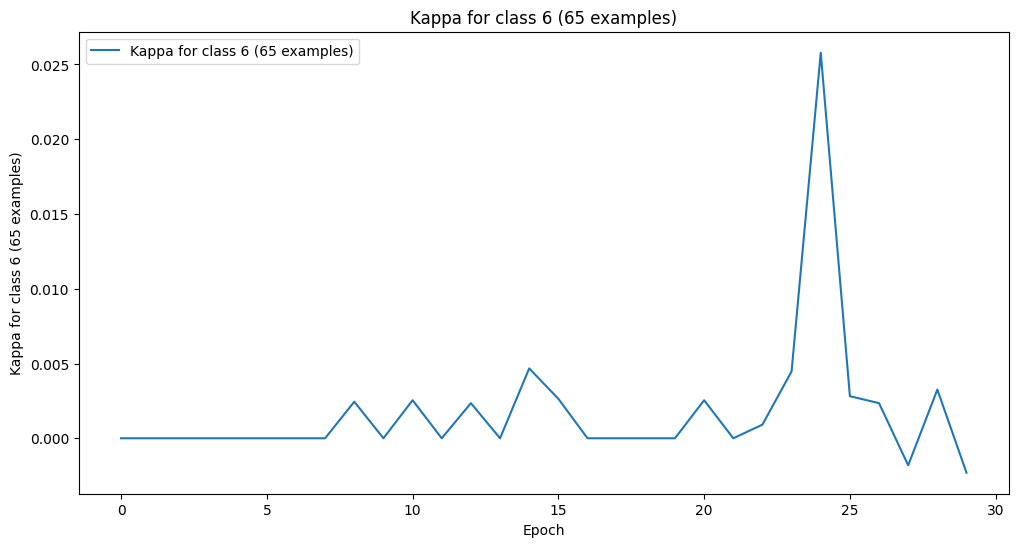

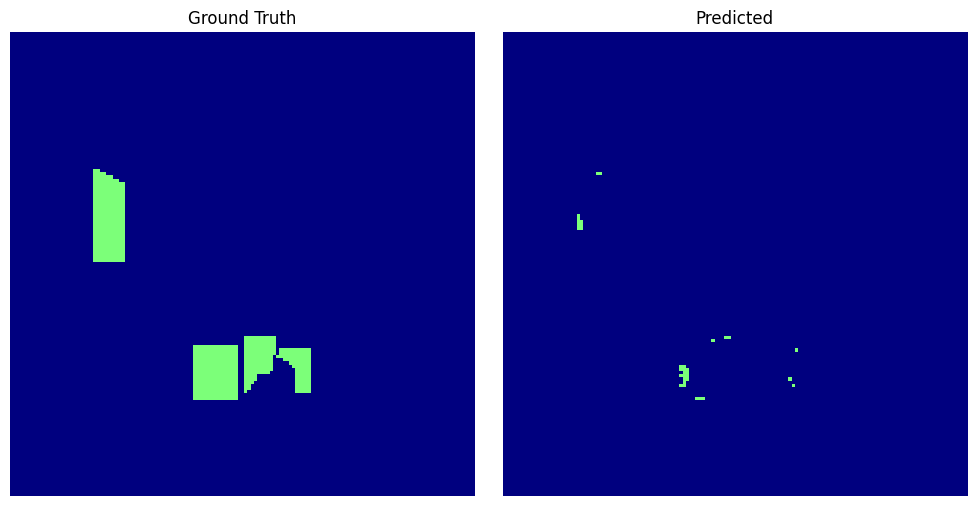

 50%|█████     | 9/18 [1:24:34<1:24:28, 563.16s/it, eval_accuracy_avg=0.965, eval_accuracy_overall=0.507, eval_f1=0.949, eval_kappa=0.0258, eval_loss=0.0567, id=65]

  0%|          | 0/30 [00:00<?, ?it/s]

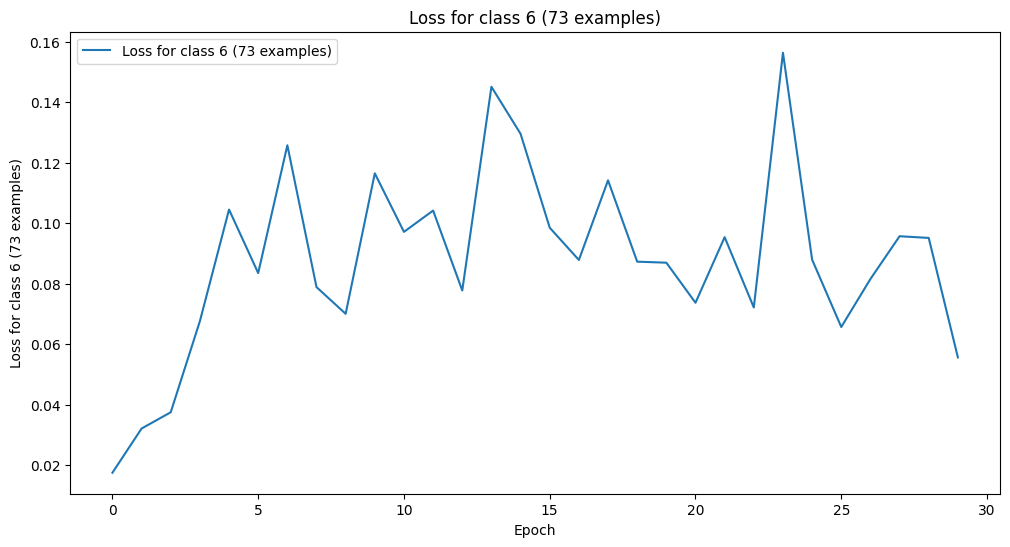

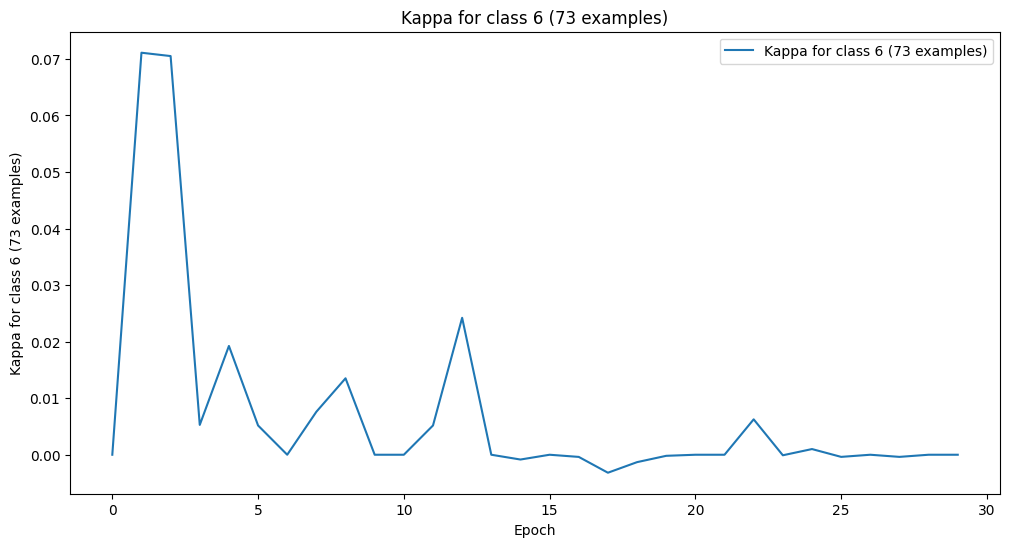

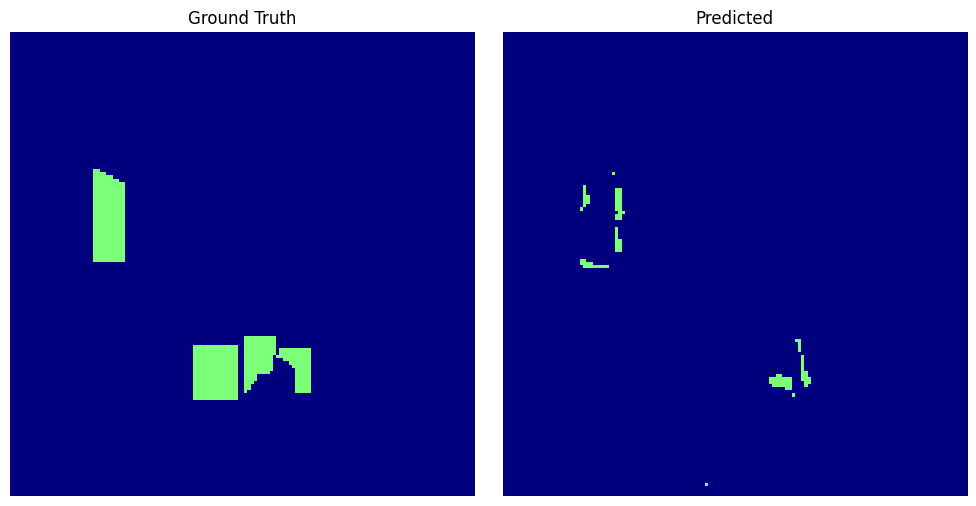

 56%|█████▌    | 10/18 [1:34:06<1:15:27, 565.91s/it, eval_accuracy_avg=0.963, eval_accuracy_overall=0.521, eval_f1=0.95, eval_kappa=0.0711, eval_loss=0.0321, id=73]

  0%|          | 0/30 [00:00<?, ?it/s]

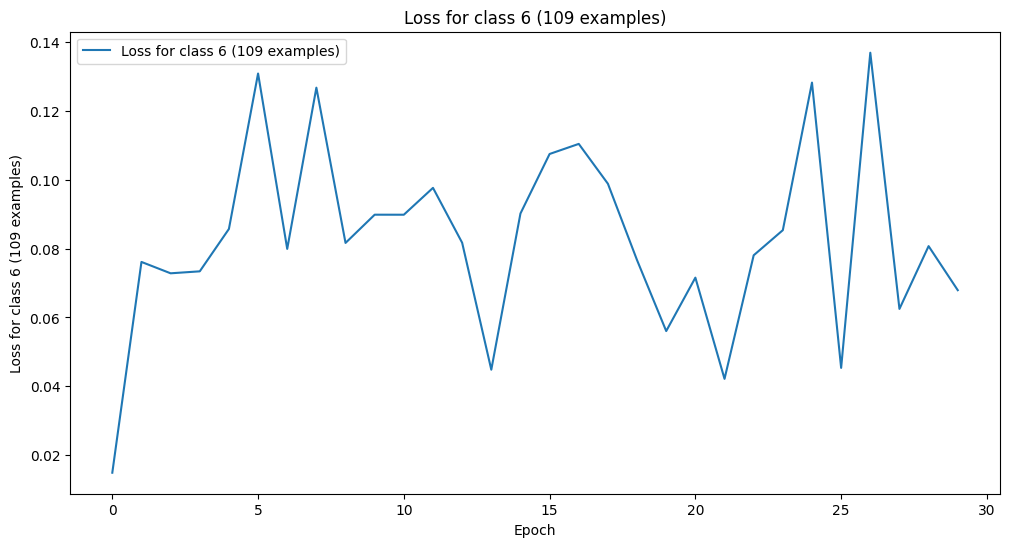

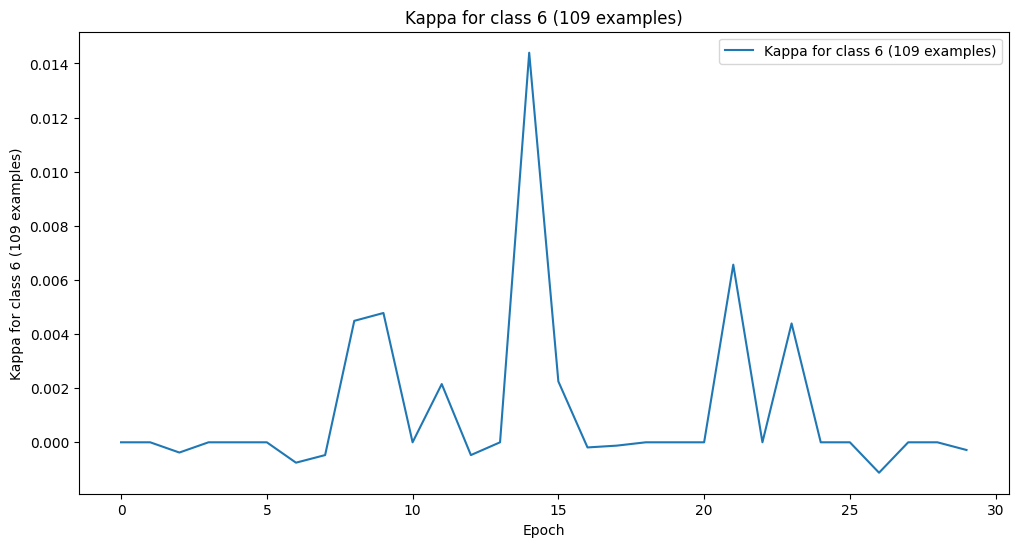

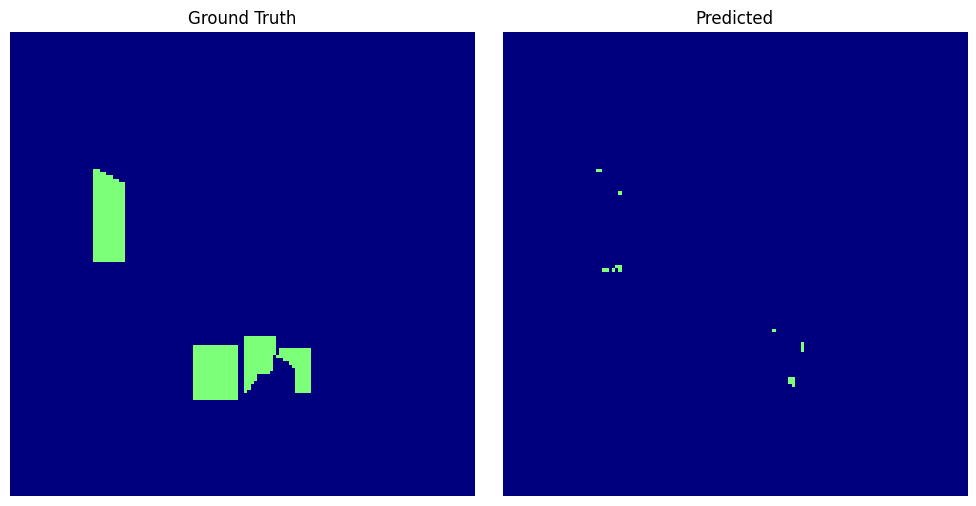

 61%|██████    | 11/18 [1:43:43<1:06:26, 569.49s/it, eval_accuracy_avg=0.965, eval_accuracy_overall=0.504, eval_f1=0.949, eval_kappa=0.0144, eval_loss=0.0902, id=109]

  0%|          | 0/30 [00:00<?, ?it/s]

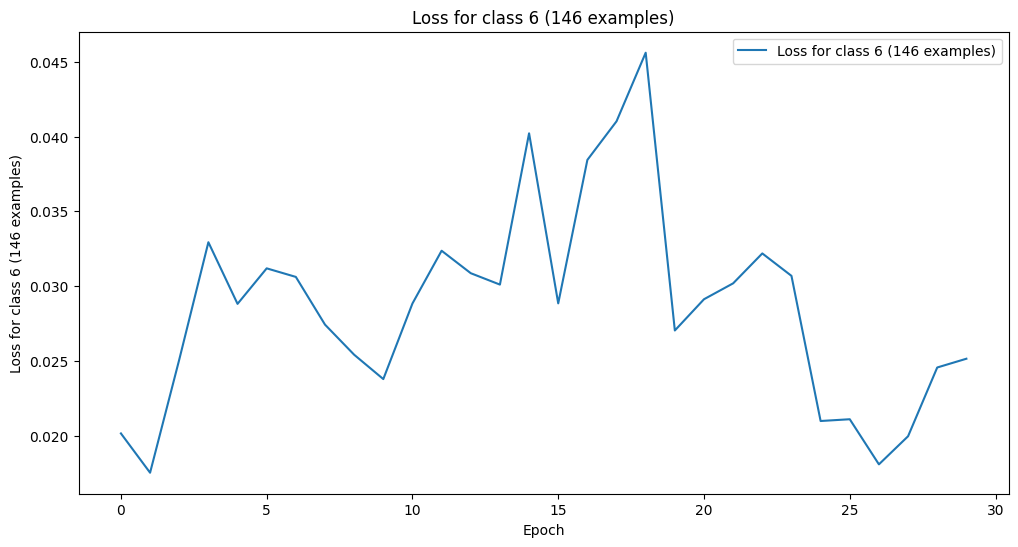

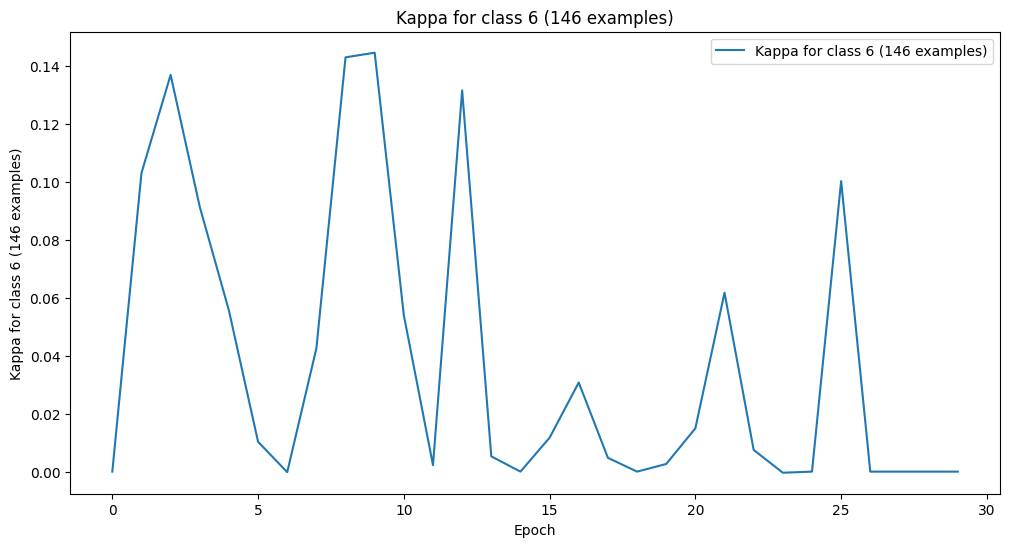

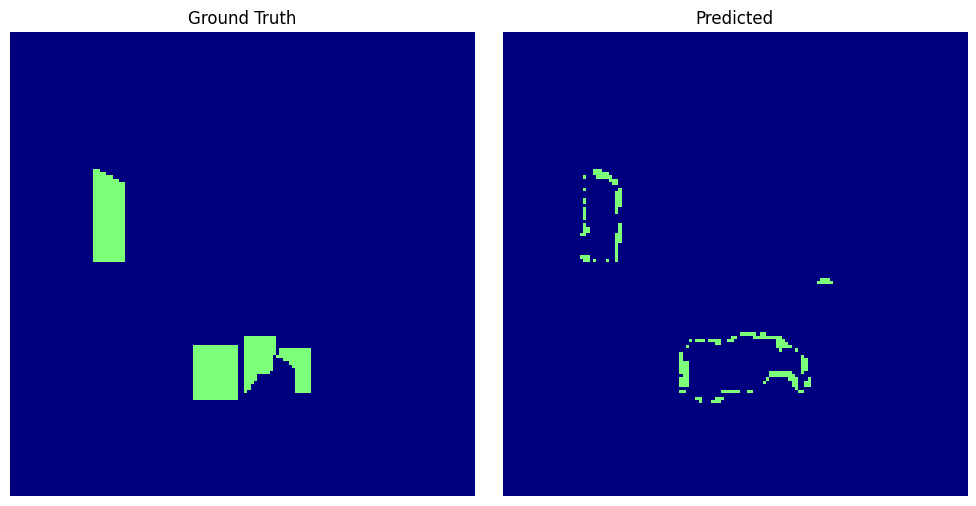

 67%|██████▋   | 12/18 [1:53:23<57:15, 572.54s/it, eval_accuracy_avg=0.962, eval_accuracy_overall=0.547, eval_f1=0.952, eval_kappa=0.145, eval_loss=0.0238, id=146]   

  0%|          | 0/30 [00:00<?, ?it/s]

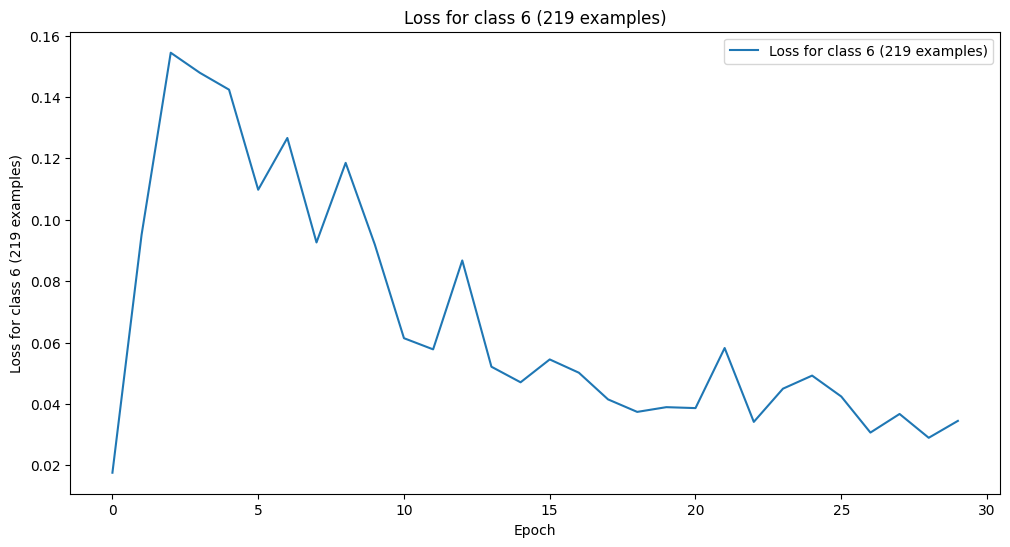

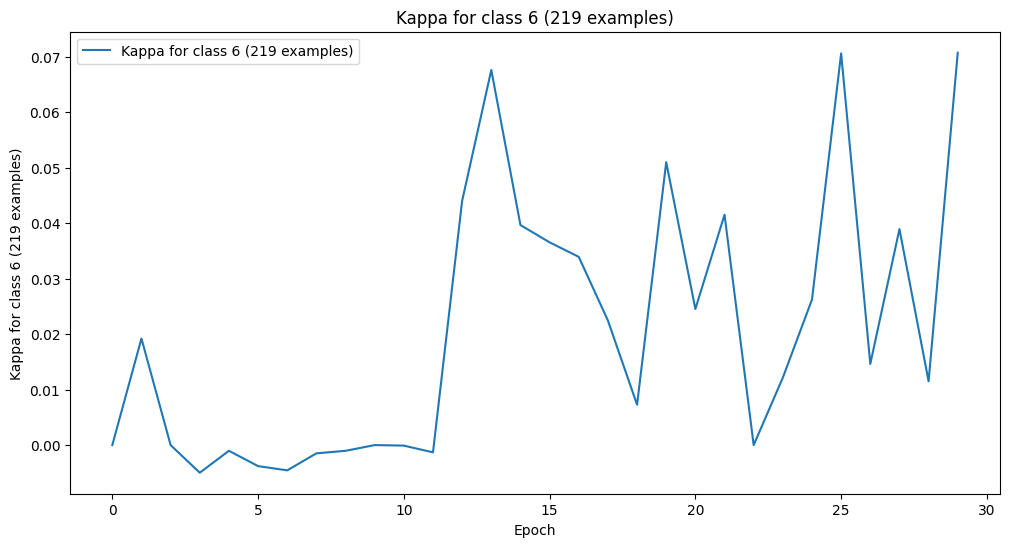

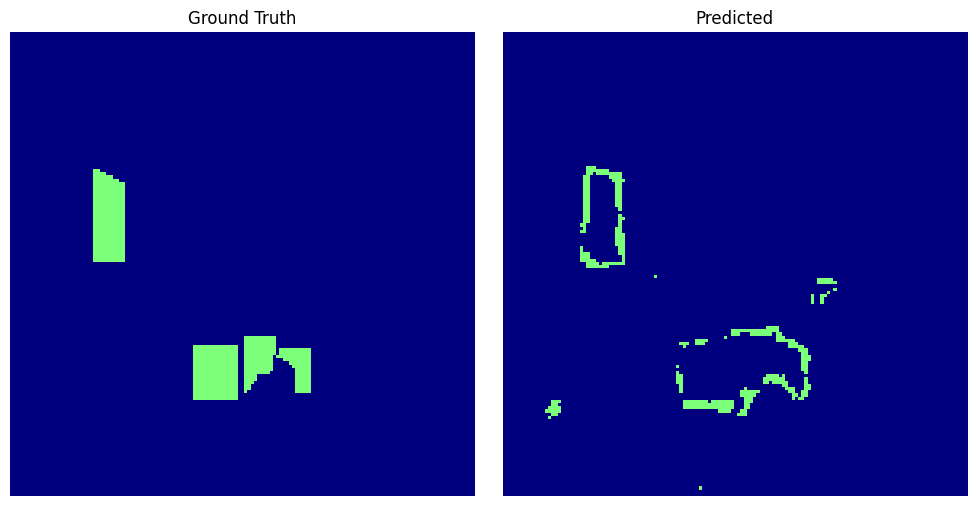

 72%|███████▏  | 13/18 [2:02:59<47:48, 573.63s/it, eval_accuracy_avg=0.952, eval_accuracy_overall=0.527, eval_f1=0.945, eval_kappa=0.0707, eval_loss=0.0345, id=219]

  0%|          | 0/30 [00:00<?, ?it/s]

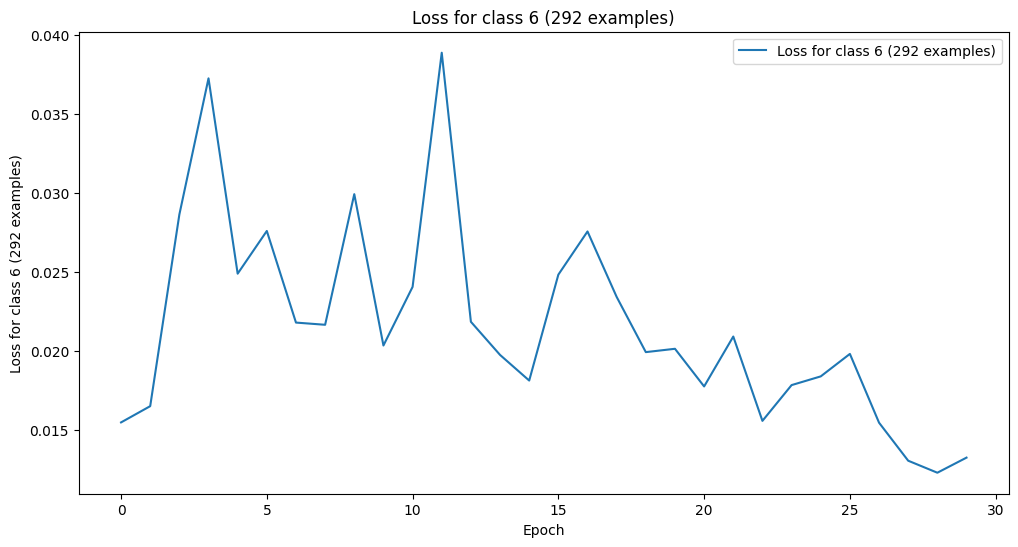

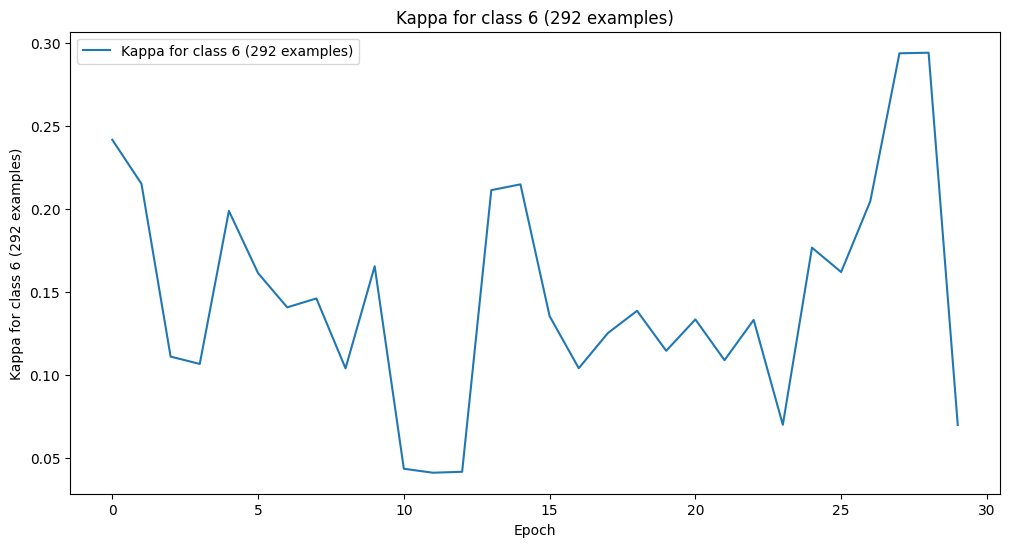

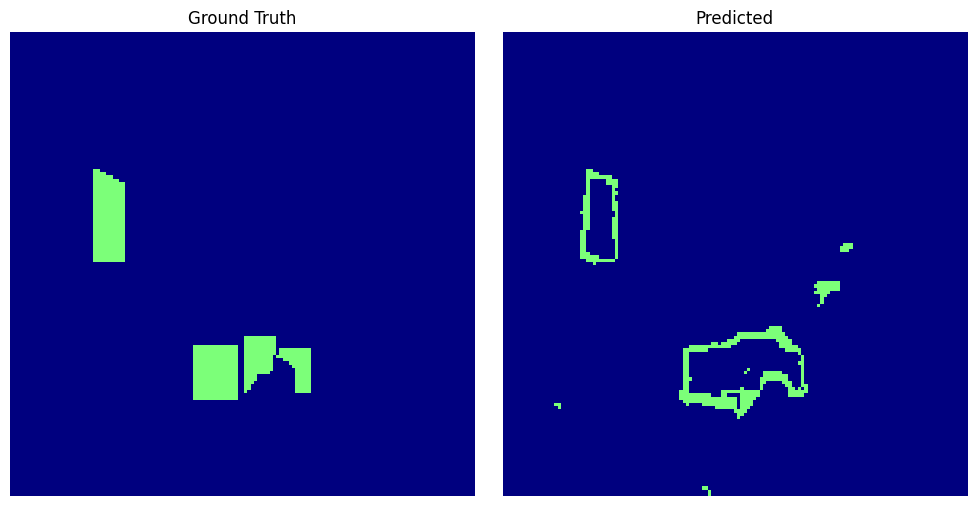

 78%|███████▊  | 14/18 [2:12:37<38:19, 574.86s/it, eval_accuracy_avg=0.961, eval_accuracy_overall=0.621, eval_f1=0.957, eval_kappa=0.294, eval_loss=0.0123, id=292] 

  0%|          | 0/30 [00:00<?, ?it/s]

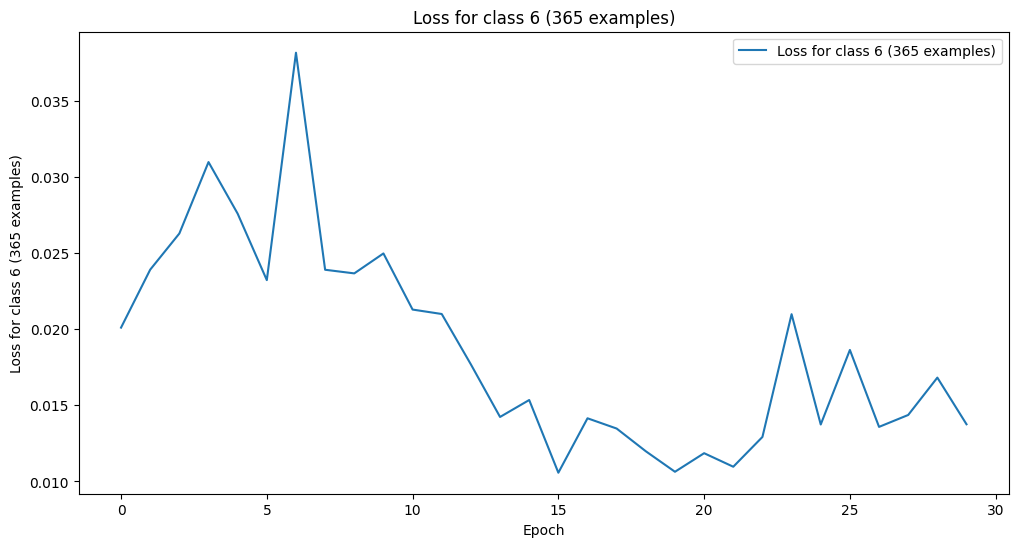

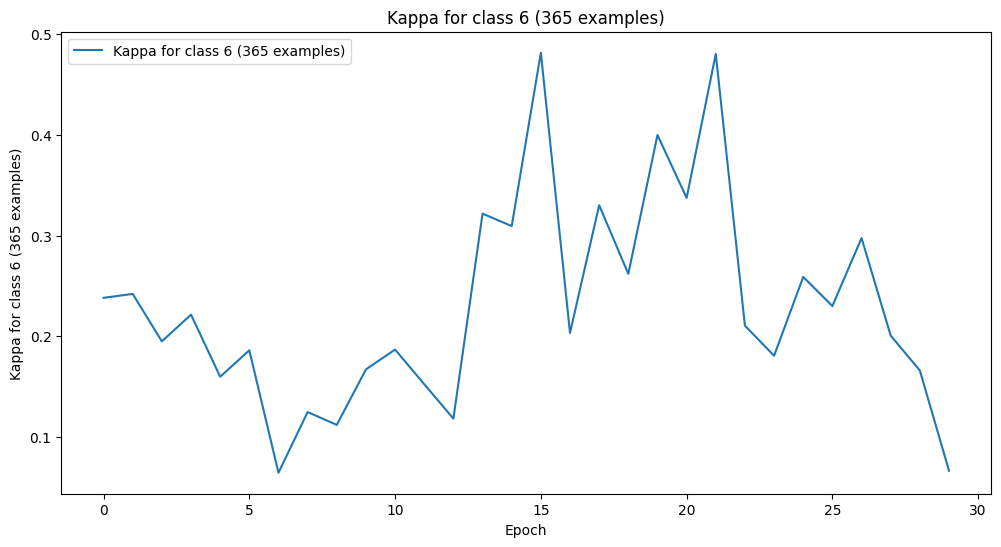

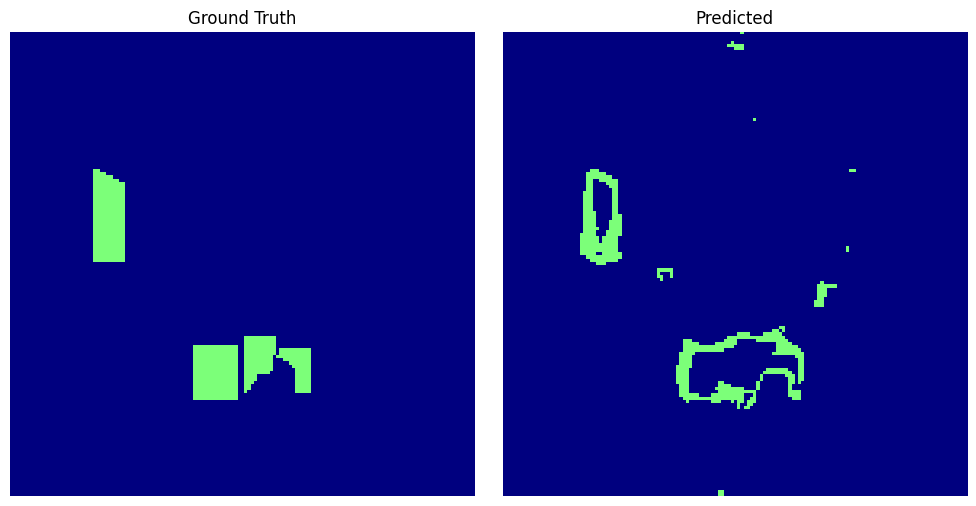

 83%|████████▎ | 15/18 [2:22:02<28:36, 572.13s/it, eval_accuracy_avg=0.968, eval_accuracy_overall=0.719, eval_f1=0.967, eval_kappa=0.482, eval_loss=0.0106, id=365]

  0%|          | 0/30 [00:00<?, ?it/s]

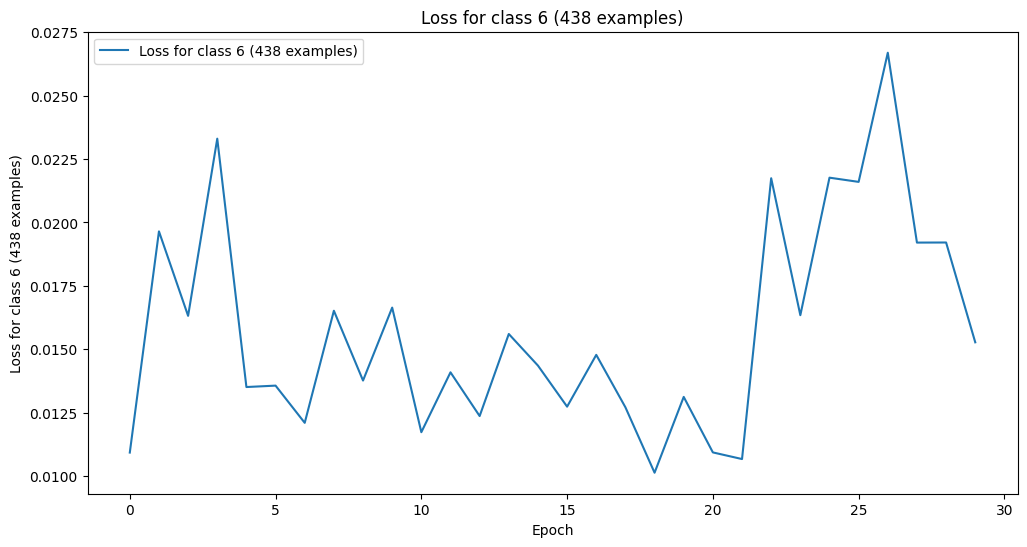

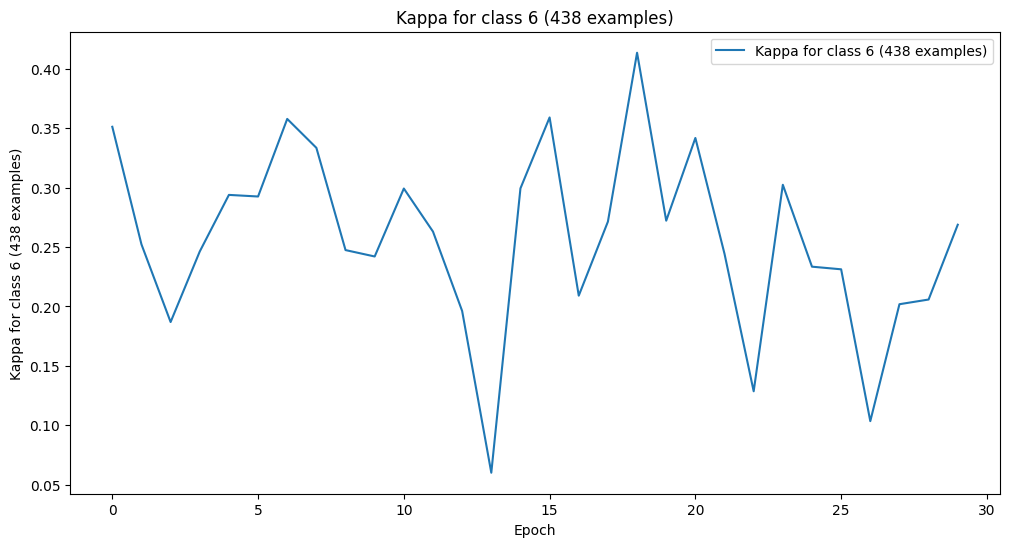

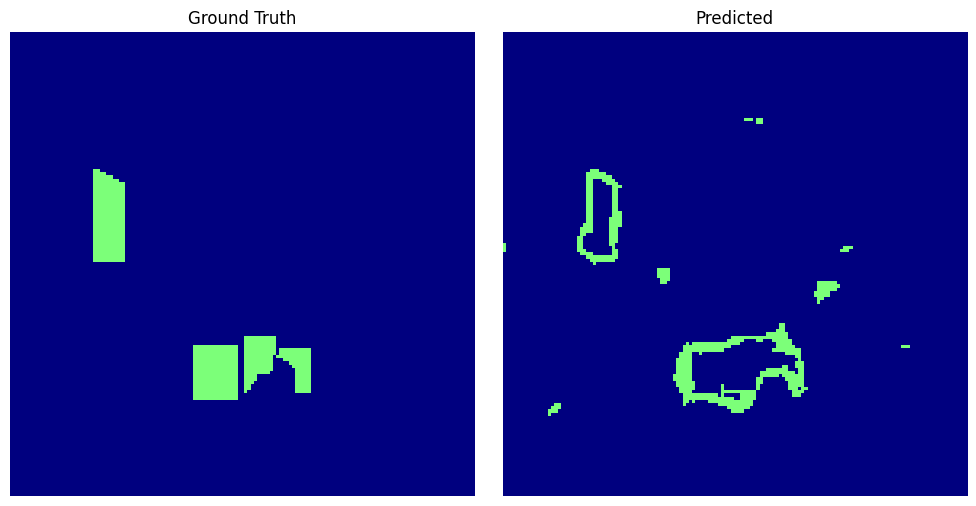

 89%|████████▉ | 16/18 [2:31:32<19:02, 571.46s/it, eval_accuracy_avg=0.964, eval_accuracy_overall=0.687, eval_f1=0.963, eval_kappa=0.413, eval_loss=0.0101, id=438]

  0%|          | 0/30 [00:00<?, ?it/s]

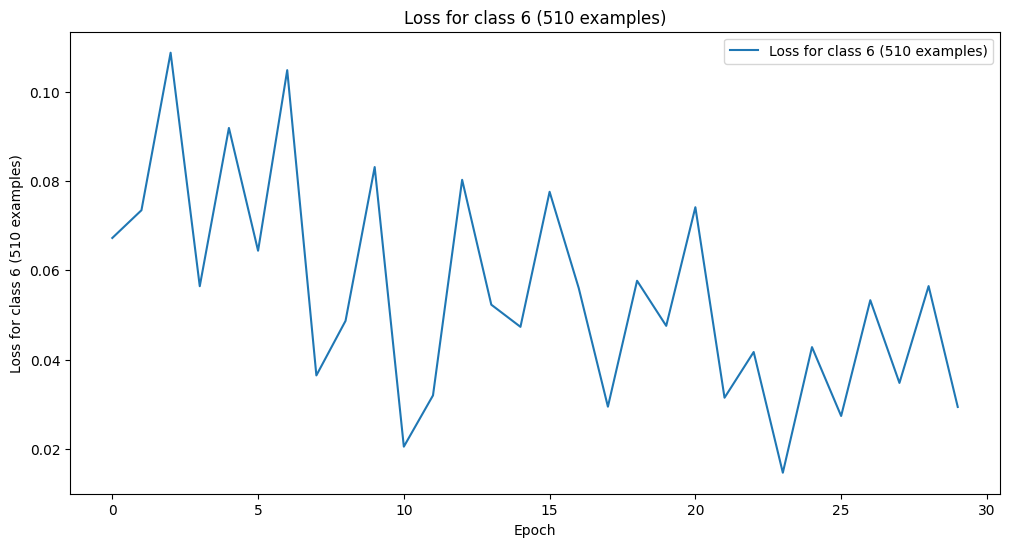

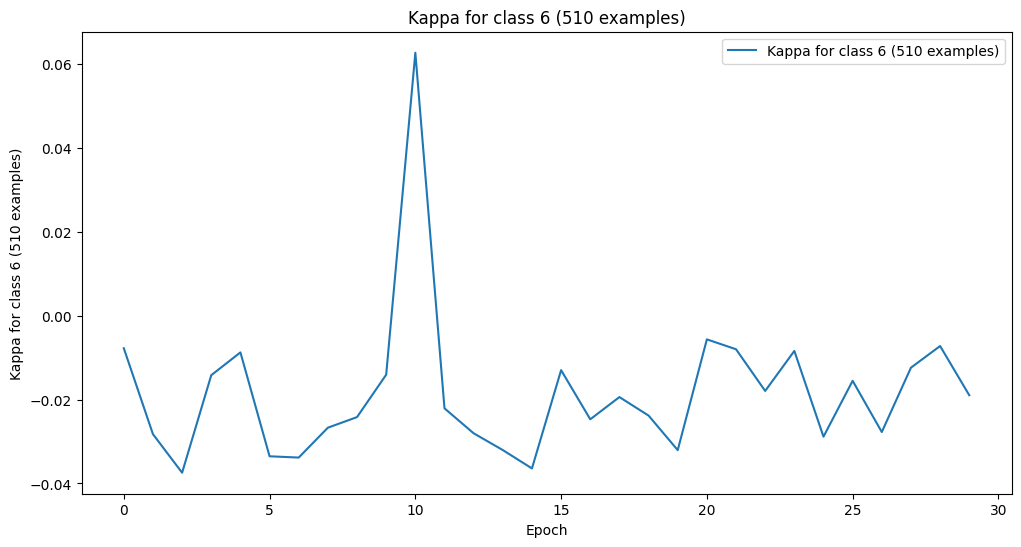

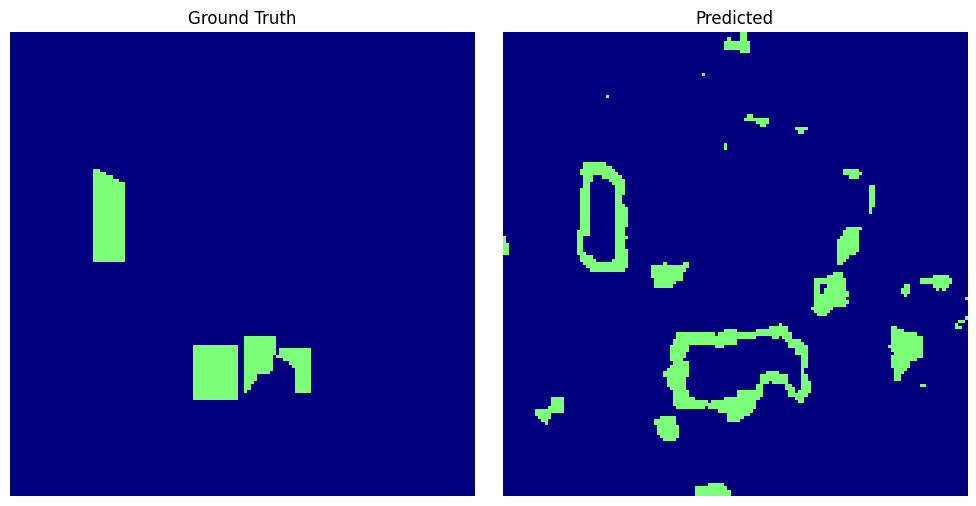

 94%|█████████▍| 17/18 [2:41:25<09:37, 577.95s/it, eval_accuracy_avg=0.912, eval_accuracy_overall=0.544, eval_f1=0.924, eval_kappa=0.0628, eval_loss=0.0206, id=510]

  0%|          | 0/30 [00:00<?, ?it/s]

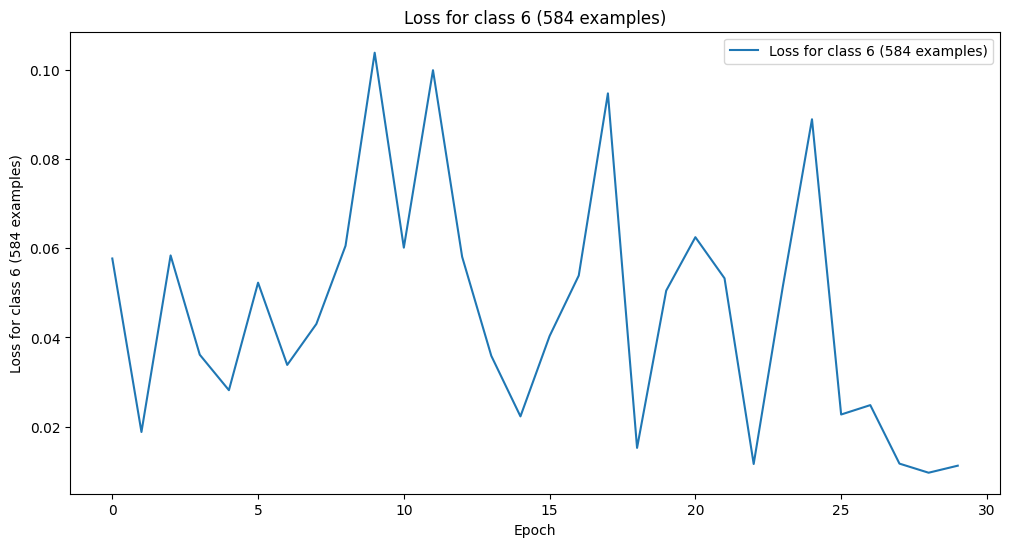

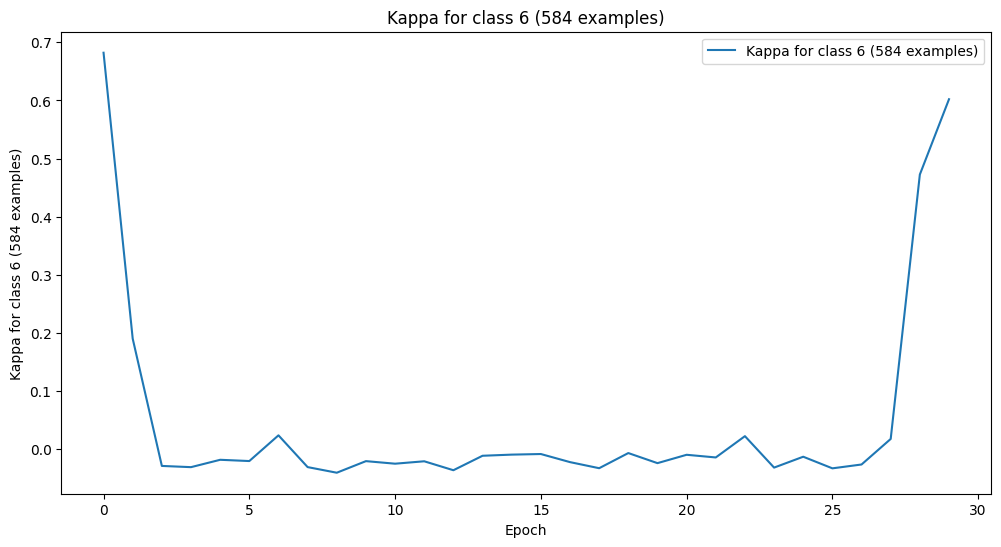

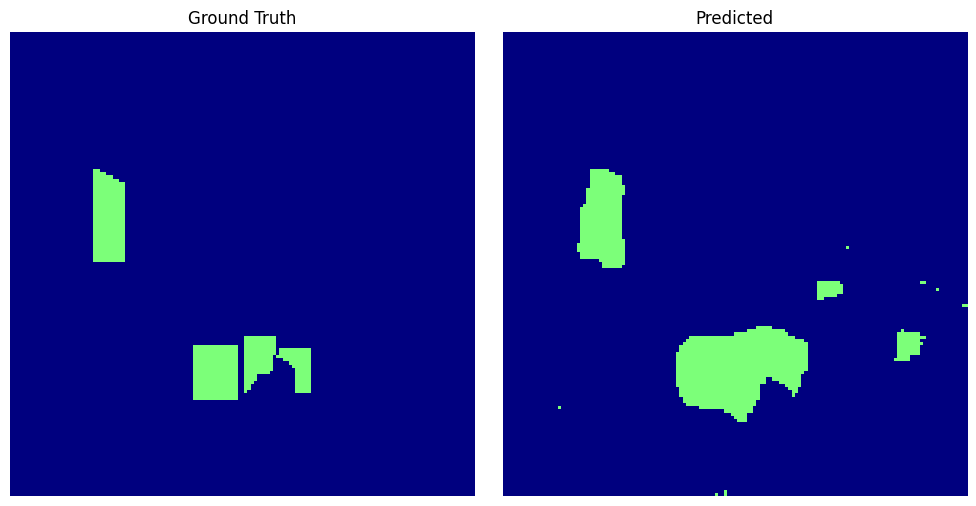

100%|██████████| 18/18 [2:50:52<00:00, 569.59s/it, eval_accuracy_avg=0.971, eval_accuracy_overall=0.972, eval_f1=0.974, eval_kappa=0.682, eval_loss=0.0577, id=584] 


In [19]:
search = RepresentativeDataPointsSearch(
    IndianPinesDatapointsSearch(target_class, skip=skip_maskes), log_dir, f"class-{target_class}"
)

feedback = search.run()

In [20]:
feedback[1]

HistoryEntry(id='14', score={'eval_f1': 0.9482258558273315, 'eval_accuracy_overall': 0.5, 'eval_accuracy_avg': 0.9652794003486633, 'eval_kappa': 0.0, 'eval_loss': 0.09909997622292817})

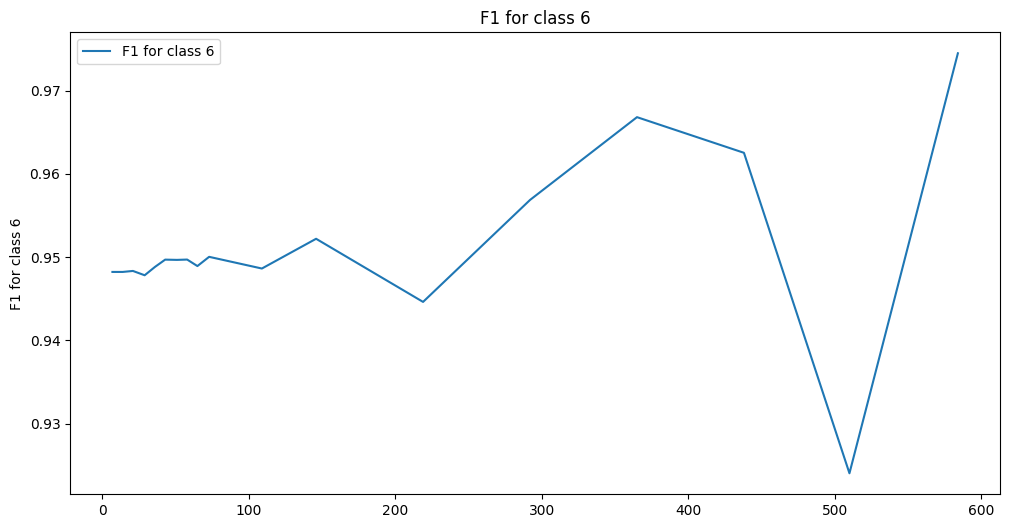

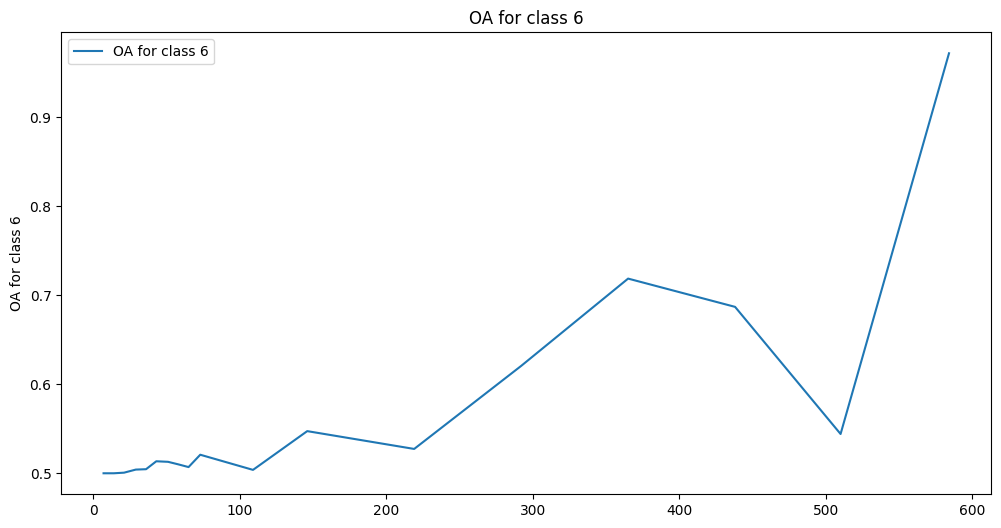

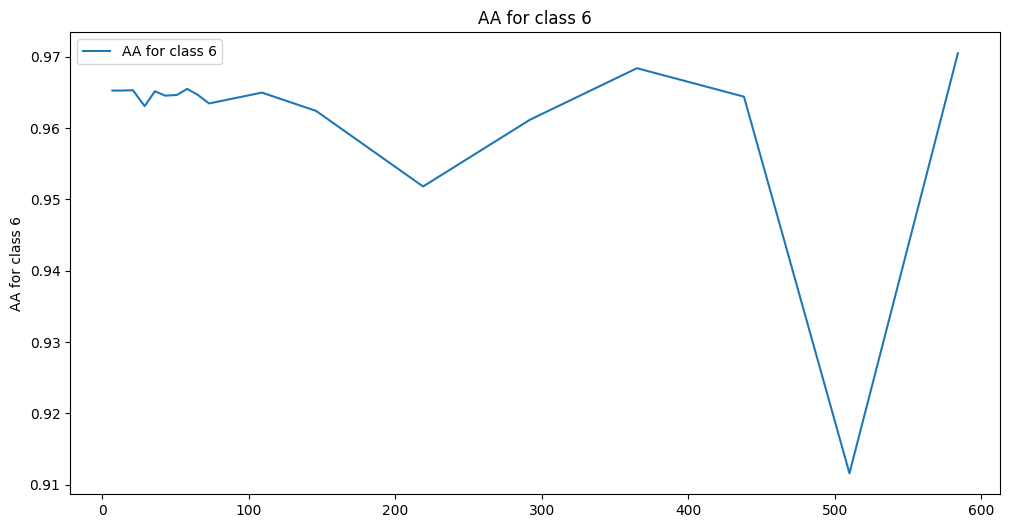

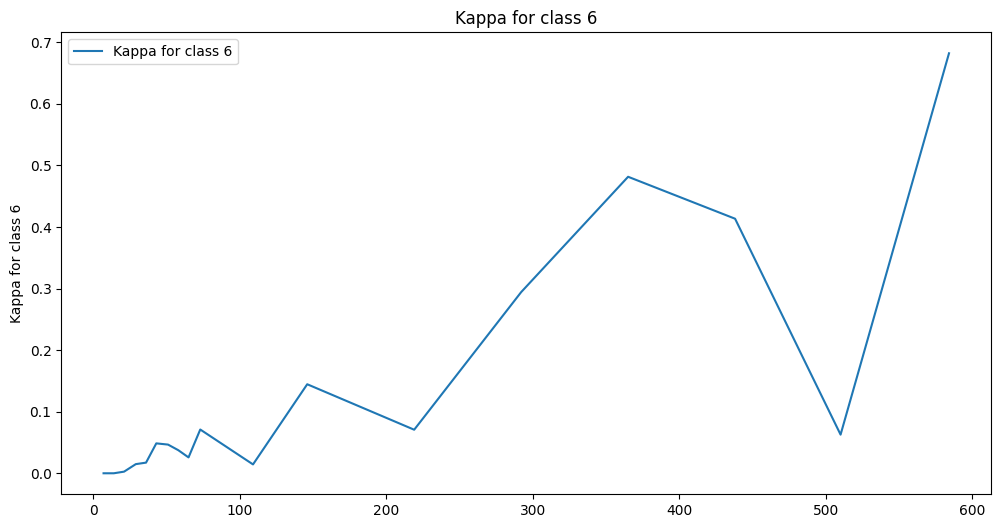

In [21]:
ids = [int(it.id) for it in feedback]
f1s = [it.score["eval_f1"] for it in feedback]
oas = [it.score["eval_accuracy_overall"] for it in feedback]
aas = [it.score["eval_accuracy_avg"] for it in feedback]
kappas = [it.score["eval_kappa"] for it in feedback]

plot_generic(ids, f1s, desc=f"F1 for class {target_class}")
plot_generic(ids, oas, desc=f"OA for class {target_class}")
plot_generic(ids, aas, desc=f"AA for class {target_class}")
plot_generic(ids, kappas, desc=f"Kappa for class {target_class}")